# Examen Python data developer
# Deel 1
## Introductie
Voor dit examen is het belangrijk dat je volgende zaken zeker doet:
 - Maak een Vitual Environment aan & exporteer een `.yml` (of soortgelijke) file aan die je toevoegt aan je codebase.
 - Maak een github pagina aan met een bijhorende `.gitignore` en `readme.md`. Voeg een link naar de github repo toe aan je readme file.
 - Zorg dat je op het einde de tijd neemt om je code op te schonen zodat deze begrijpelijk is voor derden.
 - Wanneer je klaar bent, maak een `.zip` bestand van je volledige codebase aan en laad deze op in de leeromgeving.

In deze opgave bekijken we een gesimuleerde dataset over de geboortes in België van 2019. De data is te vinden in `.csv` bestanden die gelabeld zijn met de echte geboortedag van de personen in het bestand. Laat ons bijvoorbeeld even kijken naar de eerste 5 lijnen van het bestand `2019-1-1.csv`:

<table align="center">
  <tr>
    <th>gemeente</th>
    <th>naam</th>
    <th>geslacht</th>
    <th>verwachte datum</th>
  </tr>
  <tr>
    <td>Hooglede</td>
    <td>Elias</td>
    <td>Mannelijk</td>
    <td>01/14/2019</td>
  </tr>
  <tr>
    <td>Sint-Niklaas (Sint-Niklaas)</td>
    <td>Pauline</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Wijnegem</td>
    <td>Anita</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Grâce-Hollogne</td>
    <td>Jean-Paul</td>
    <td>Mannelijk</td>
    <td>01/13/2019</td>
  </tr>
  <tr>
    <td>Boussu</td>
    <td>François</td>
    <td>Mannelijk</td>
    <td>01/26/2019</td>
  </tr>
</table>


Hier hebben we de kolommen:
 - **gemeente**: De gemeente waar de persoon geboren is.
 - **naam**: De voornaam van de persoon.
 - **geslacht**: Het geslacht van de persoon (Mannelijk of Vrouwelijk).
 - **verwachte datum**: De verwachte geboortedatum van de persoon.

Dus hier hebben we dan bijvoorbeeld op de eerste lijn de mannelijke persoon Elias die geboren is in Hooglede waarvan men verwachtte dat hij zou geboren worden op `01/14/2019` (Amerikaans formaat) maar in feite geboren is op 1 januari 2019.

Doorheen deze opgave gaan we de data van dichterbij inspecteren! Je kan deze opgaves alternatief lezen in de bijgeleverde notebook `examen.ipynb` waar ook de (meeste) afbeeldingen & resultaten zichtbaar zijn.

## Visualisaties

Wanneer er je gevraagd wordt een visualisatie te maken krijg je minimale instructies. Tijdens de lessenreeks zagen we een heel aantal best practices, pas deze toe ook al wordt dit niet telkens expliciet aangegeven in de instructies.


## Puntenverdeling
**Het totale examen staat op X punten.**

Mondelinge toelichting voor alles
 - 50%: Je snapt wat je gedaan hebt.
 - 50%: Je kan bijvragen beantwoorden

## Utilities

In [119]:
def clean_plot(*args):
    ax = plt.gca()
    
    # Mapping van nummers naar de namen van de 'spines'
    mapping = {1: 'bottom', 2: 'left', 3: 'top', 4: 'right'}
    
    # 1. Speciaal geval: 0 verwijdert ALLES
    if 0 in args:
        for spine in ax.spines.values():
            spine.set_visible(False)
        return # Stop hier, de rest is niet meer nodig

    # 2. Standaard geval: Geen argumenten verwijdert Top (3) en Right (4)
    if not args:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # 3. Specifieke gevallen: Verwijder alleen de meegegeven nummers
    else:
        for num in args:
            if num in mapping:
                ax.spines[mapping[num]].set_visible(False)

# --- Test scenarios ---
# clean_plot(0)         # Volledig frame weg
# clean_plot()          # Top en Right weg (default)
# clean_plot(1, 3)      # Alleen Bottom en Top weg
# clean_plot(1, 2, 3, 4) # Verwijdert het volledige frame

## Imports

In [2]:
import pandas as pd
import numpy as np
#import glob
#import os
from pathlib import Path

import matplotlib.pyplot as plt
from scipy.stats import linregress
#from sklearn.linear_model import LinearRegression
from tqdm.auto import tqdm
from time import time


## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

---

### Laden en converteren 
###### onbestaande schrikkeldag reeds naar df_wrong

In [3]:
start1 = time()
# 1. BESTANDEN LADEN
path = Path('../data/geboortes')
all_files = path.glob("*.csv")

df_list = []
for file_path in all_files:
    df_temp = pd.read_csv(file_path)
    
    # file_path.stem geeft direct de bestandsnaam zonder .csv
    df_temp['date_str'] = file_path.stem
    
    df_list.append(df_temp)
    
# 2. SAMENVOEGEN
df_births = pd.concat(df_list, axis=0, ignore_index=True)

# voor vergelijking aantal rijen
old_df_births = df_births.copy()

# 3. CLEANING EN CONVERSIES
# datetime conversie, coerce= markeren als NaT
df_births['date'] = pd.to_datetime(df_births['date_str'], errors='coerce')
df_births['verwachte datum'] = pd.to_datetime(df_births['verwachte datum'], errors='coerce')

# 'date'-NaTs naar df_wrong verplaatsen
df_wrong = df_births[df_births['date'].isna()].copy()
df_wrong['reden'] = "Onbestaande datum (2019 is geen schrikkeljaar)"
df_births = df_births.dropna(subset=['date'])

# Verwijder de hulpkolom
df_births.drop(columns=['date_str'], inplace=True)

# category type conversie
df_births['geslacht'] = df_births['geslacht'].astype('category')
df_births['gemeente'] = df_births['gemeente'].astype('category')


# 3. TOEVOEGEN 'dag_van_jaar' (1-365)
df_births['dag_van_jaar'] = df_births['date'].dt.dayofyear #dt =toegang krijgen tot de datum- en tijdseigenschappen van een Series

# 'dag_van_jaar' -> integer
df_births['dag_van_jaar'] = df_births['dag_van_jaar'].astype('Int16')

# 4a. TE TONEN CHECKS1: aantallen en bereiken
print("CHECKS")
print("    AANTALLEN EN BEREIKEN")
#Aantal rijen in df_births
print(f"Aantal rijen in df_births voor deleting 29feb: {len(old_df_births)}")
print(f"Aantal rijen in df_births na: {len(df_births)}")

#Minimum- en maximumdatum
print(f"\nMinimumdatum: {df_births['date'].min()}")
print(f"Maximumdatum: {df_births['date'].max()}")

#Minimum en maximum van day_of_year
print(f"\nMinimum dag_van_jaar: {df_births['dag_van_jaar'].min()}")
print(f"Maximum dag_van_jaar: {df_births['dag_van_jaar'].max()}")

# 4b. TE TONEN CHECKS2: fouten
print("\n    DATUMFOUTEN")
# Check jaartallen
print(f"Controleer jaartallen in 'date': {df_births['date'].dt.year.unique()}")
print(f"Controleer jaartallen in 'verwachte datum': {df_births['verwachte datum'].dt.year.unique()}")

# Check Nan-values
print(f"\nCheck Nan-values in 'date': {df_births['date'].isna().sum()}")
print(f"Check Nan-values in 'verwachte datum': {df_births['date'].isna().sum()}")

# Check dagnummers in 'date'
invalid_day = (df_births['dag_van_jaar'] < 1) | (df_births['dag_van_jaar'] > 365)
print(f"\nOnlogische nummers in 'dag_van_jaar': {invalid_day.sum()}\n")

display(df_births.head(3))
print(f"duration: {time() - start1:.3f}s")
#7.6s/

CHECKS
    AANTALLEN EN BEREIKEN
Aantal rijen in df_births voor deleting 29feb: 116923
Aantal rijen in df_births na: 116850

Minimumdatum: 2019-01-01 00:00:00
Maximumdatum: 2019-12-31 00:00:00

Minimum dag_van_jaar: 1
Maximum dag_van_jaar: 365

    DATUMFOUTEN
Controleer jaartallen in 'date': [2019]
Controleer jaartallen in 'verwachte datum': [2019 2018 2020]

Check Nan-values in 'date': 0
Check Nan-values in 'verwachte datum': 0

Onlogische nummers in 'dag_van_jaar': 0



,gemeente,naam,geslacht,verwachte datum,date,dag_van_jaar
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,1
1,Sint-Niklaas (Sint-Niklaas),Pauline,Vrouwelijk,2019-01-05,2019-01-01,1
2,Wijnegem,Anita,Vrouwelijk,2019-01-05,2019-01-01,1


duration: 7.575s


## Stap 2: EDA

In [ ]:
print("INFO")
display(df_births.info())
print("\nDESCRIBE include=object")
display(df_births.describe(include='object'))
print("DESCRIBE")
display(df_births.describe())
print("\nNUNIQUE")
display(df_births.nunique())
print("\nCHECK FOR DUPLICATES")
display(df_births.duplicated().any()) # Returns True if any duplicate rows exist
print("\nCHECK FOR NaNs") # already checked with .info()
print(df_births.isna().sum())

### Vraag 1: Initial Plot

Maak een plot van het aantal geboortes per dag van het jaar. Gebruik een horizontale rode stippellijn om het gemiddelde aan te geven. (1 pnt)

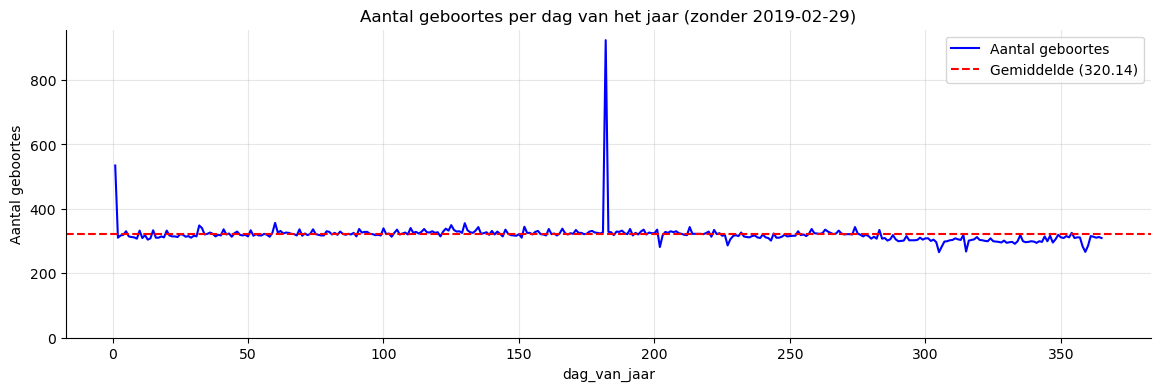

gemiddelde_geboortes: 320.1


In [122]:
import matplotlib.pyplot as plt

# Groepeer per dag van het jaar en tel het aantal geboortes
births_per_day = df_births.groupby('dag_van_jaar').size()

# Bereken het gemiddelde
gemiddelde_geboortes = births_per_day.mean()

# Plotten
plt.figure(figsize=(14, 4))
births_per_day.plot(kind='line', color='blue', label='Aantal geboortes')

# Horizontale rode stippellijn voor het gemiddelde
plt.axhline(y=gemiddelde_geboortes, color='red', linestyle='--', label=f'Gemiddelde ({gemiddelde_geboortes:.2f})')
#plt.axhline(y=gemiddelde_geboortes, color='red', linestyle='--') # geen legende label

# Opmaak volgens best practices
plt.title('Aantal geboortes per dag van het jaar (zonder 2019-02-29)')
plt.xlabel('dag_van_jaar')
plt.ylabel('Aantal geboortes')
plt.yticks(range(0, 1000, 200)) # Ticks om de 200
plt.legend()
plt.grid(True, alpha=0.3)
clean_plot() #geen top en right kaderlijn, vermindering 'non-data ink'

plt.show()


# Extra check uit de vraag: toon het gemiddelde resultaat
print(f"gemiddelde_geboortes: {gemiddelde_geboortes:.1f}")



#### VoorbeeldPlot Vraag 1

(0.0, 955.9)

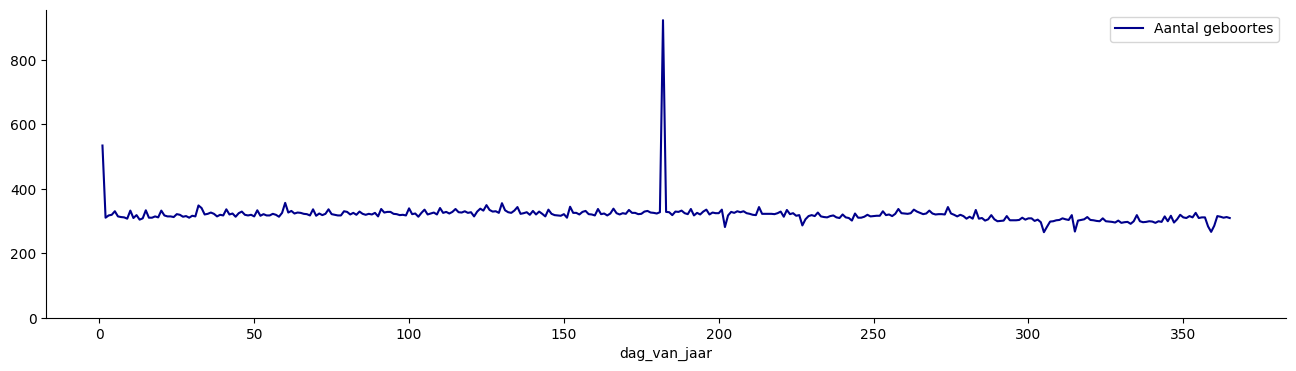

### Vraag 2: Outliers vinden & behandelen

#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [12]:
# Bepalen Outliners grenslijn
#bepalen grenslijn outliers
print(f"top3 births_per_day:\n {births_per_day.nlargest(5)}")
print(f"Gemiddelde: {gemiddelde_geboortes:.1f}")

top3 births_per_day:
 dag_van_jaar
182    923
1      534
60     356
130    355
125    349
dtype: int64
Gemiddelde: 320.1


#### *** Comment Vraag 2, Outliers regel:
-Aan de hand van 'top3 births_per_day' en gemiddelde van 320.1 werd de grens gezet op '> 400 geboortes per dag'.

In [13]:
# Dagen met de hoogste aantallen
counts = df_births.groupby('date').size()
# Outliers zijn dagen met > 400 geboortes (terwijl gem. 320 is)
outliers = counts[counts > 400].index.tolist()

outliers

[Timestamp('2019-01-01 00:00:00'), Timestamp('2019-07-01 00:00:00')]

#### VoorbeeldResult Vraag2.1

[Timestamp('2019-01-01 00:00:00'), Timestamp('2019-07-01 00:00:00')]

#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.


#### *** Comment Vraag 2.2, Outliers patroon:

 **Patroon:**  
-1/1 en 1/7 zijn extreme uitschieters (ca. 900+/500+ geboortes).  
-Dit zijn mogelijk administratieve default datums indien geboortedatum niet nauwkeurig gekend is.  
**Strategie:**  
-In plaats van data te corrigeren, verplaatsen we deze rijen naar df_wrong. 
-Dit garandeert dat onze trendanalyse in df_births_clean niet vervuild wordt door administratieve defaults of foute input.

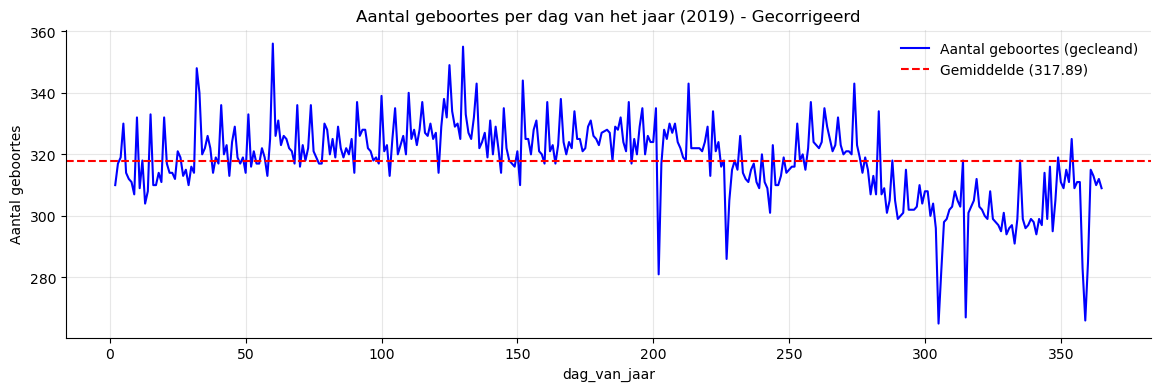

gemiddelde_geboortes (na cleaning): 317.9


In [123]:
# PLOT AANTAL GEBOORTES PER DAG VAN HET JAAR

# 1. Identificatie van alle outliers (Administratief + Onbestaande datums)
# Administratieve pieken (gevonden in Vraag 2.1)
admin_outlier_dates = outliers

# 2.Voeg de administratieve pieken toe aan df_wrong
df_admin_peaks = df_births[df_births['date'].isin(admin_outlier_dates)].copy()
df_admin_peaks['reden'] = "Potentiële administratieve default datum (piek in data)"

df_wrong = pd.concat([df_wrong, df_admin_peaks], ignore_index=True) # samenvoegen met 29-02-29 groep

# 3. Maak df_births_clean
# We droppen de NaT's en filteren de administratieve pieken eruit
df_births_clean = df_births.dropna(subset=['date'])
df_births_clean = df_births_clean[~df_births_clean['date'].isin(admin_outlier_dates)]

# 4. Hermaak de figuur op basis van df_births_clean
births_per_day_clean = df_births_clean.groupby('dag_van_jaar').size()
gemiddelde_clean = births_per_day_clean.mean()

plt.figure(figsize=(14, 4))
births_per_day_clean.plot(kind='line', color='blue', label='Aantal geboortes (gecleand)')

# Horizontale rode stippellijn voor het nieuwe gemiddelde
plt.axhline(y=gemiddelde_clean, color='red', linestyle='--', label=f'Gemiddelde ({gemiddelde_clean:.2f})')

# Opmaak volgens best practices
plt.title('Aantal geboortes per dag van het jaar (2019) - Gecorrigeerd')
plt.xlabel('dag_van_jaar')
plt.ylabel('Aantal geboortes')

# Schaal en Ticks
#plt.xlim(1, 365)
#plt.yticks(range(0, 1000, 200)) # Ticks om de 200 zoals gevraagd

# Styling
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
clean_plot() # Verwijdert top en right spines (minder non-data ink)

plt.show()

# Extra check: toon het nieuwe gemiddelde
print(f"gemiddelde_geboortes (na cleaning): {gemiddelde_clean:.1f}")


#### VoorbeeldPlot Vraag 2.2
-Deze voorbeeld-grafiek heeft **geen 'gemiddelde' lijn**, eerder een grenslijn om outliners te scheiden.

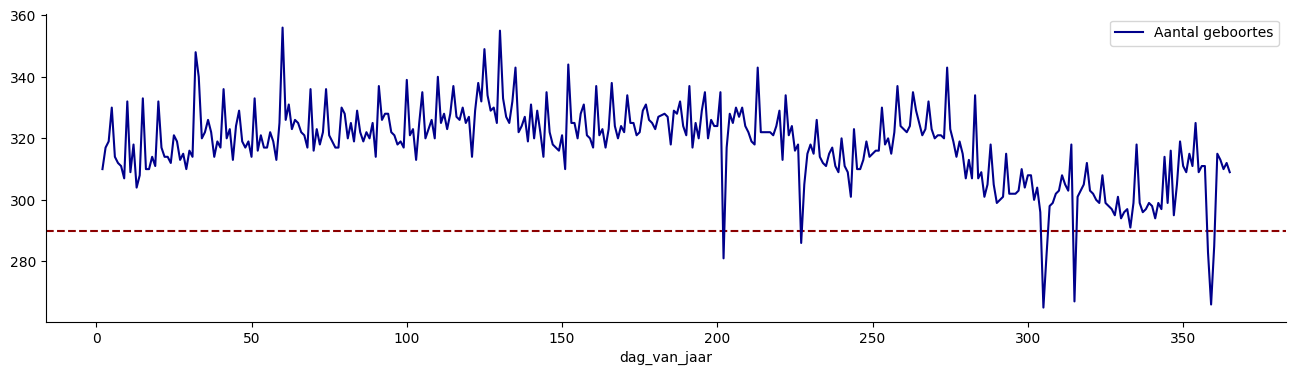

In [ ]:
AFWIJKEND GEMIDDELDE

#### Vraag 2.3 Identificeer de **8 meest extreme** dagen in de tweede helft van het jaar. (1 pnt)

In [16]:
# MEEST EXTREME DAGEN = GROOTSTE ABS(AFWIJKING) TOV GEMIDDELDE

# Filter tweede helft/semester van het jaar (dag 183 t/m 365)
tweede_sem_clean = df_births_clean[df_births_clean['dag_van_jaar'] >= 183]

# Aantal geboortes per dag in 2de semester
per_day_2sem = tweede_sem_clean.groupby(['dag_van_jaar', 'date']).size().reset_index(name='Aantal geboortes')
# Gemiddelde 2de semester
gemiddelde_2sem = per_day_2sem['Aantal geboortes'].mean()

# Afstanden tot het gemiddelde
per_day_2sem['distance'] = per_day_2sem[['Aantal geboortes']] - gemiddelde_2sem
#display("per_day_2sem")
#display(per_day_2sem)

# Sorteer op absolute waarde, van groot naar klein
# 'key' parameter om de sorteerregel aan te passen
#'key'=>Kijk niet naar het getal zelf, maar naar de uitkomst van abs(getal)
extreme_2sem = per_day_2sem.sort_values(by='distance', key=abs, ascending=False)

print("extreme_2sem \nTOP 8")
df_top = extreme_2sem.head(8).copy()
df_top = df_top[['dag_van_jaar', 'Aantal geboortes', 'distance']]
display(df_top.style.format({'distance': '{:.0f}'})) #print 3 decimals but keep full precision

print("LAAGSTE 8")
df_lowest = extreme_2sem.nsmallest(8, 'Aantal geboortes').copy()
df_lowest= df_lowest[['date', 'dag_van_jaar', 'Aantal geboortes', 'distance']]#.sort_values('dag_van_jaar')
display(df_lowest.style.format({'distance': '{:.0f}'}))


extreme_2sem 
TOP 8


,dag_van_jaar,Aantal geboortes,distance
122,305,265,-47
176,359,266,-46
132,315,267,-45
19,202,281,-31
30,213,343,31
91,274,343,31
123,306,282,-30
175,358,283,-29


LAAGSTE 8


,date,dag_van_jaar,Aantal geboortes,distance
122,2019-11-01 00:00:00,305,265,-47
176,2019-12-25 00:00:00,359,266,-46
132,2019-11-11 00:00:00,315,267,-45
19,2019-07-21 00:00:00,202,281,-31
123,2019-11-02 00:00:00,306,282,-30
175,2019-12-24 00:00:00,358,283,-29
177,2019-12-26 00:00:00,360,285,-27
44,2019-08-15 00:00:00,227,286,-26


#### Plot extremen

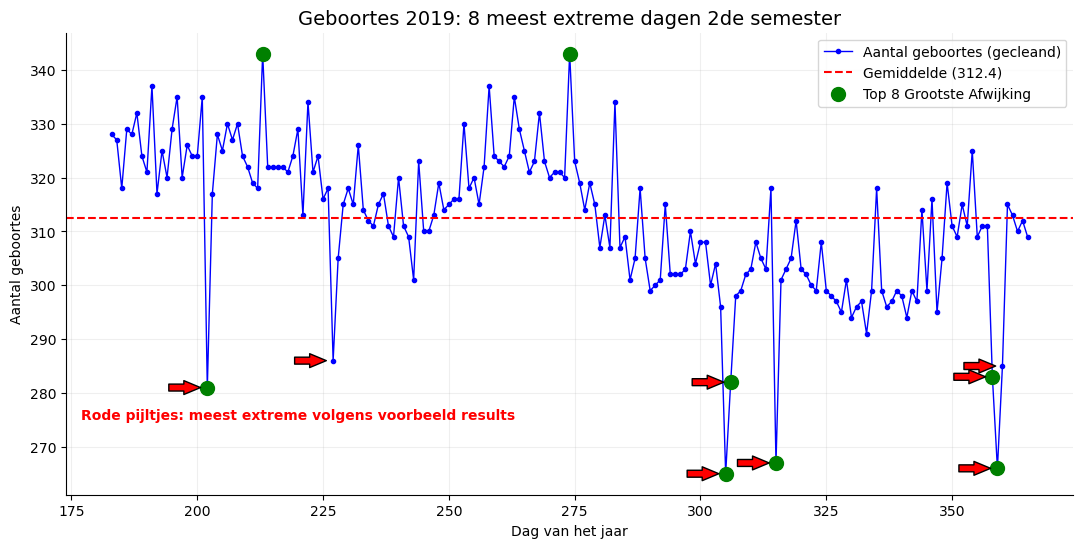

In [125]:
# PLOT MEEST AFWIJKENDE DATA
# 1. 8 meest afwijkende dagen (absolute afwijking)
top8_afwijkend = extreme_2sem.head(8)

# 2. de 8 dagen met de laagste aantallen (uit de 2de helft)
# We pakken de 8 kleinste waarden uit de reeks van de 2de helft
laagste_8 = extreme_2sem.nsmallest(8, 'Aantal geboortes')

# 3. gemiddelde_sem(ester) en sort per_day_2sem
#gemiddelde_2sem = per_day_2sem['Aantal geboortes'].mean()
per_day_2sem.sort_values(by='dag_van_jaar', inplace=True)

# 4. --- PLOTTEN ---
plt.figure(figsize=(13, 6))

# Basislijn
plt.plot(per_day_2sem['dag_van_jaar'], 
         per_day_2sem['Aantal geboortes'], 
         color='blue', 
         marker='o',         # Voegt de cirkeltjes toe
         markersize=3,       # Houdt de dots subtiel
         linewidth=1,        # Iets dunnere lijn zodat de dots opvallen
         label='Aantal geboortes (gecleand)')
# Gemiddelde lijn
plt.axhline(y=gemiddelde_2sem, color='red', linestyle='--', label=f'Gemiddelde ({gemiddelde_2sem:.1f})', zorder=2)

# MARKERING 1: Groene dots voor 8 meest afwijkende dagen tov gemiddelde.
plt.scatter(top8_afwijkend['dag_van_jaar'], top8_afwijkend['Aantal geboortes'], 
            color='green', s=100, label='Top 8 Grootste Afwijking', zorder=3)

# MARKERING 2: Rode pijltjes voor de 8 LAAGSTE 'Aantal geboortes'-waarden 
for _, row in laagste_8.iterrows():
    plt.annotate('', 
                 xy=(row['dag_van_jaar']-1, row['Aantal geboortes']), # Punt van de pijl
                 xytext=(row['dag_van_jaar']-8, row['Aantal geboortes']), # Start van de pijl (linkser)
                 arrowprops=dict(facecolor='red', shrink=0.05, width=5, headwidth=10))

# Voeg de beschrijvende tekst toe voor laagste_8-pijl markeringen
plt.text(220, 
         275,
         'Rode pijltjes: meest extreme volgens voorbeeld results', 
         color='red', 
         ha='center', 
         fontweight='bold',
         fontsize=10)

# 4.Opmaak
plt.title('Geboortes 2019: 8 meest extreme dagen 2de semester', fontsize=14)
plt.xlabel('Dag van het jaar')
plt.ylabel('Aantal geboortes')
plt.legend(frameon=True, loc='upper right')
plt.grid(True, alpha=0.2)
clean_plot()

plt.show()
#display(top8_afwijkend)
#extreme_2sem.nsmallest(8, 'Aantal geboortes')

#### *** Comment Vraag 2.3  
-De extremen in 'Voorbeeld result Vraag 2.3' hieronder, zijn de 8 laagste geboortecijfer-waarden van de 2de semester (rode pijlen).  
-De bovenstaande zijn de extremen tov de gemiddelde waarden (groene dots).  
-Ter vergelijking zijn beide weergegeven in de plot.

#### VoorbeeldResult Vraag 2.3

In [ ]:
AFWIJKENDE EXTREMEN

,date,dag_van_jaar,Aantal geboortes
199,2019-07-21,202,281
224,2019-08-15,227,286
302,2019-11-01,305,265
303,2019-11-02,306,282
312,2019-11-11,315,267
355,2019-12-24,358,283
356,2019-12-25,359,266
357,2019-12-26,360,285


### Vraag 3: Verbanden per week/maand

#### Vraag 3.1 (2 pnt)
We zien vele pieken en dalen in de evolutie van het aantal geboortes. We willen deze grafiek graag iets "gladder" maken. Kan je hiervoor eens een visualizatie maken van het **gemiddeld** aantal geboortes per week (dit voor elke week, dus maandag-maandag, dinsdag-dinsdag, woensdag-woensdag, ...).


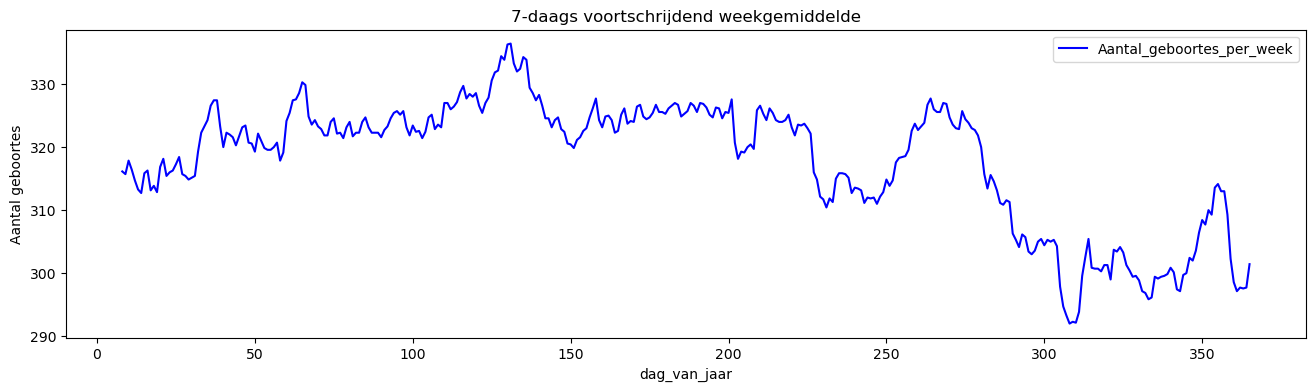

In [126]:
# BEREKEN EEN 7-DAAGS ROLLEND GEMIDDELDE

# 1.center = False gemiddelde vn heel de week ervoor, eerste 6 dagen Nan
# 2.center = True gemiddelde van 3dagen ervoor en 3dagen er na, begin en eindpunt 3 dagen Nan
rolling_births1 = births_per_day_clean.rolling(window=7, center=False).mean() 
rolling_births2 = births_per_day_clean.rolling(window=7, center=True).mean()
#print(f"CENTER= FALSE:\n {rolling_births1}")
#print(f"\nCENTER= TRUE:\n {rolling_births2}")

plt.figure(figsize=(16, 4))
rolling_births1.plot(color='blue', label='Aantal_geboortes_per_week')
plt.title('7-daags voortschrijdend weekgemiddelde')
plt.xlabel('dag_van_jaar')
plt.ylabel('Aantal geboortes')
plt.legend()
plt.show()

#### VoorbeeldPlot Vraag 3.1

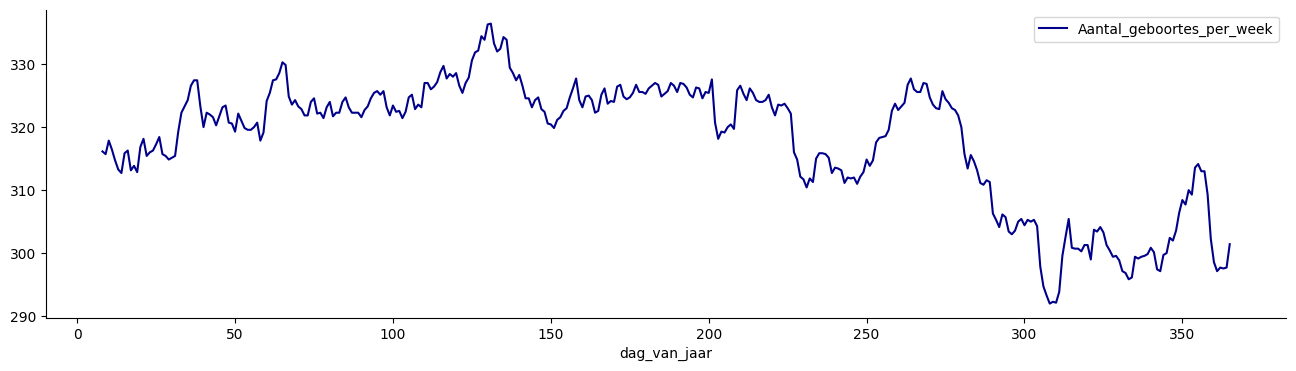

#### Vraag 3.2 (2 pnt)
Dat ziet er al een stuk mooier uit!  We zien ook een aantal duidelijk dips & pieken verschijnen die we eerder niet zagen. We kunnen nu ook even kijken naar het gemiddeld aantal geboortes per dag van de week! Misschien worden er wel gewoon veel minder mensen geboren op zondag dan een andere dag?

In [127]:
# DAG VAN DE WEEK TOEVOEGEN
df_weekday = df_births_clean.copy()
df_weekday['day_name'] = df_weekday['date'].dt.day_name()

# Gemiddelde berekenen per dag van de week
# eerst het totaal aantal geboortes per unieke dag datum
geboortes_per_weekdag = df_weekday.groupby(['date', 'day_name']).size().reset_index(name='aantal')
#dan het gemiddelde van per weekdag.
weekdag_gemiddelde = geboortes_per_weekdag.groupby('day_name')['aantal'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])
display(weekdag_gemiddelde.round(2))

day_name
Monday       316.78
Tuesday      317.31
Wednesday    317.42
Thursday     317.77
Friday       318.15
Saturday     318.98
Sunday       318.77
Name: aantal, dtype: float64

In [ ]:
df_weekday
geboortes_per_weekdag

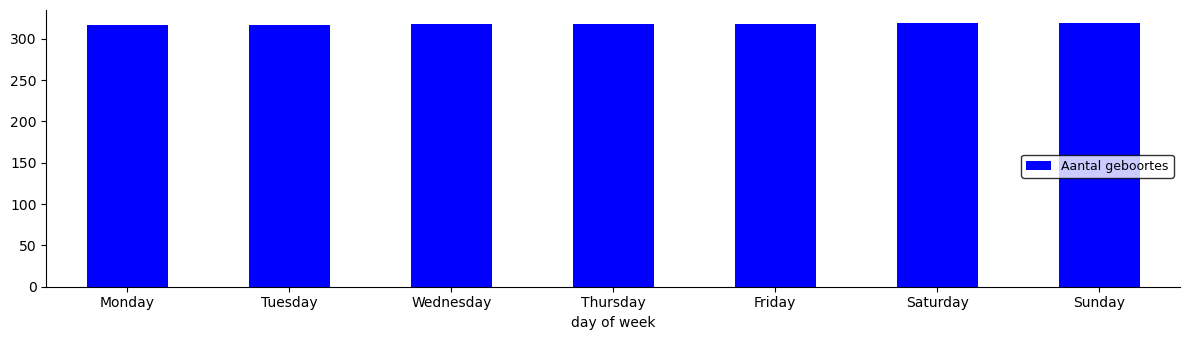

In [128]:
# WEEKDAG GEMIDDELDE PLOT
# Figuur aanmaken
fig, ax = plt.subplots(figsize=(12, 3.5))

# De bars plotten
weekdag_gemiddelde.plot(kind='bar', color='blue', ax=ax, width=0.5, label='Aantal geboortes')

# Styling conform voorbeeld
ax.set_xlabel('day of week')
ax.set_ylabel('') # Leeg laten zoals in voorbeeld
ax.set_xticklabels(weekdag_gemiddelde.index, rotation=0) # Horizontale tekst onderaan

#ax.legend(loc='lower center', bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9) # Legende rechtsmidden

leg = ax.legend(
    loc='upper right',          # Basispositie (rechtsboven)
    bbox_to_anchor=(1.0, 0.5), # Verplaatsen: (x, y) relatief t.o.v. de assen
                                # 1.0 is de uiterst rechtse bar, 1.15 is erboven
    facecolor='white',          # Achtergrondkleur (bijv. 'lightgrey' of 'white')
    edgecolor='black',          # Randkleur van het kader
    framealpha=0.8,             # Transparantie: 0 (onzichtbaar) tot 1 (ondoorzichtig)
    fontsize=9
)
# Verwijder bovenste en rechter lijnen (Spines)
clean_plot()

plt.tight_layout()
plt.show()

#### *** Comment bij 'Voorbeeld plot' Vraag 3.2  
-Deze is met totale jaarsom per weekdag gemaakt. Door bvb **groupby(['day_name']).size()** ipv groupby(['date', 'day_name']).size()

#### VoorbeeldPlot Vraag 3.2 

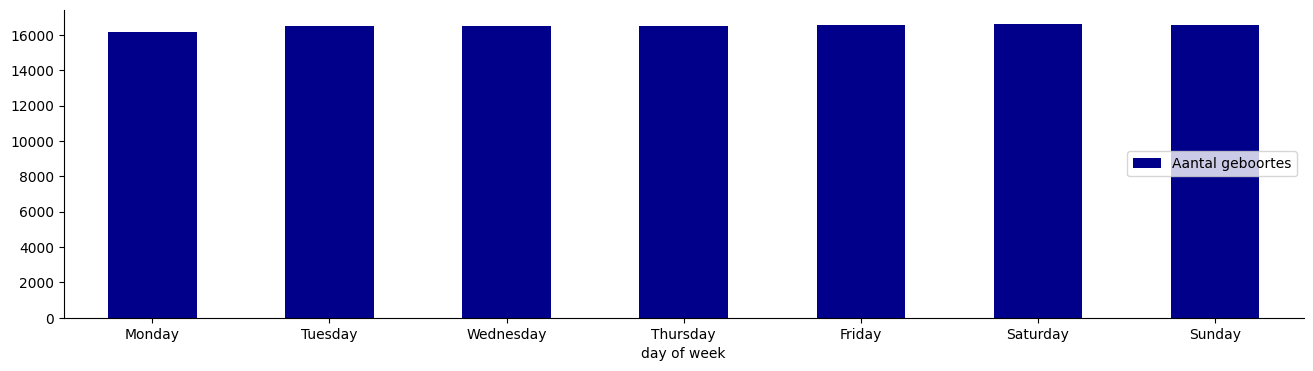

In [ ]:
AFWIJKEND GEMIDDELD VS TOTAAL

#### Vraag 3.3 — Maandverschillen in geboortes (3pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Maak één visualisatie die het gemiddeld aantal geboortes per maand toont
en tegelijk toelaat om de variatie binnen elke maand te vergelijken.

De visualisatie moet:
- de maanden tonen in chronologische volgorde (januari → december)
- per maand het gemiddelde aantal geboortes tonen
- per maand de onzekerheid rond dat gemiddelde tonen op 95% betrouwbaarheid en gebaseerd op de dagwaarden (niet handmatig berekend)



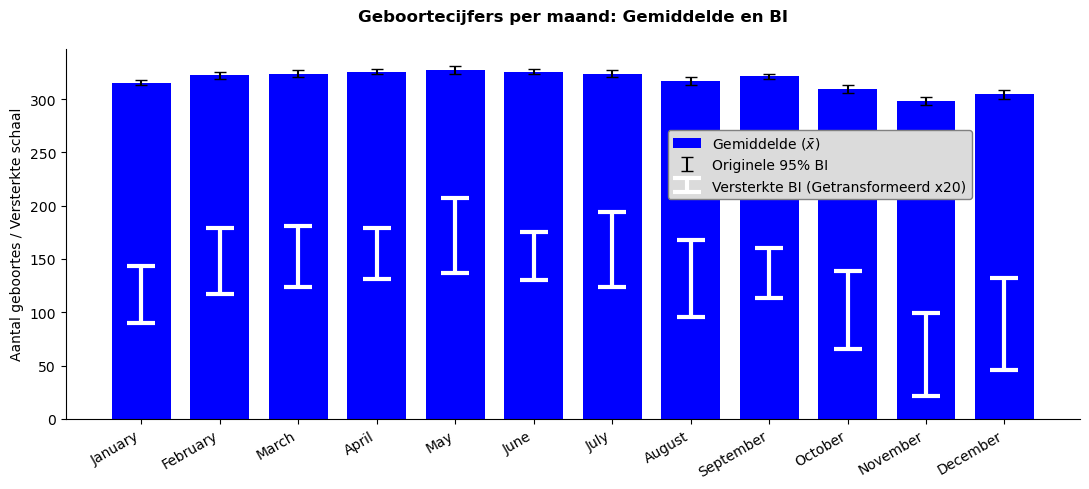

In [129]:
# GEBOORTECIJFERS PER MAAND/ GEMIDDELDEN EN BI

# 1. Bereken dagtotalen (Basis voor x_bar en sigma)
df_daily = df_births_clean.groupby('date').size().reset_index(name='dag_totaal')
df_daily['maand'] = df_daily['date'].dt.month_name()


# 2. Aggregatie per maand: bereken x_bar, sigma en n
stats = df_daily.groupby('maand')['dag_totaal'].agg(
    x_bar='mean', 
    sigma='std', 
    n='count'
)

# 3. Chronologische volgorde forceren
maanden_volgorde = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]
# Convert to categorical with specified order
#df_daily['maand'] = df_daily['maand'].astype('category')
df_daily['maand'] = pd.Categorical(df_daily['maand'], categories=maanden_volgorde, ordered=True)
stats = stats.reindex(maanden_volgorde)



# 4. Bereken SE en 95% BI (z = 1.96)
# SE = sigma / sqrt(n)
z = 1.96
stats['SE'] = stats['sigma'] / np.sqrt(stats['n'])
stats['BI_foutmarge'] = z * stats['SE']

# 5. Transformatie voor visuele versterking (Witte markers)
# Gebaseerd op jouw formules voor trend- en variatieversterking
stats['marker_bottom'] = (stats['x_bar'] - 298) * 4 + 20
stats['marker_length'] = stats['BI_foutmarge'] * 20

# Omzetten naar center/yerr voor de plot-functie
stats['marker_center'] = stats['marker_bottom'] + (stats['marker_length'] / 2)
stats['marker_yerr'] = stats['marker_length'] / 2

# 6. Visualisatie
fig, ax = plt.subplots(figsize=(11, 5))

# Blauwe bars: Het gemiddelde (x_bar), voorbeeldplot color='#3274a1'
ax.bar(stats.index, stats['x_bar'], 
       color='blue', width=0.75, label=r'Gemiddelde ($\bar{x}$)', zorder=1) 
        # 'r' voor herkenning LaTex code (standaard voor het schrijven van complexe wiskundige formules)

# Zwarte error bars: Het werkelijke 95% BI
ax.errorbar(stats.index, stats['x_bar'], yerr=stats['BI_foutmarge'], 
            fmt='none', ecolor='black', capsize=4, zorder=2, label='Originele 95% BI')

# Witte markers: Versterkte weergave van variatie en trend
ax.errorbar(stats.index, stats['marker_center'], yerr=stats['marker_yerr'], 
            fmt='none', ecolor='white', capsize=10, elinewidth=3, markeredgewidth=3,
            zorder=3, label='Versterkte BI (Getransformeerd x20)')

# Grafiek afwerking
ax.set_title('Geboortecijfers per maand: Gemiddelde en BI', fontweight='bold', pad=20)
ax.set_ylabel('Aantal geboortes / Versterkte schaal')
#ax.set_ylim(0, 400) # Ruimte voor de getransformeerde markers

# Legenda met grijze achtergrond voor contrast met wit
ax.legend(loc='upper right', facecolor='#dbdbdb', bbox_to_anchor=(0.9, 0.8), framealpha=1, edgecolor='gray') # #f0f0f0

# Layout verbeteringen
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

#### *** Comment bij plot 'Geboortecijfers per maand'  
-Getransformeerde BI=> *20, onderste bodem punt komt overeen met de getransformeerde gemiddelde bar =>(bar-298)*4+20  
-> Voor visuele versterking.

In [ ]:
display(df_daily)
display(stats['ci95'])
display(stats_gemiddelde)

#### *** Comment bij Vraag 3.3   
**Analyse van de Maandelijkse Geboortevariatie**  
Om de maandelijkse variatie te visualiseren, zijn eerst de dagtotalen berekend.  
Op basis van de spreiding van deze dagwaarden is het 95% betrouwbaarheidsinterval (BI) bepaald.  
Dit interval geeft de onzekerheid van het maandgemiddelde weer.  
De onzekerheid rondom het gemiddelde wordt berekend met de volgende formule: $BI_{95\%} = \bar{x} \pm z \cdot SE$  

Toelichting van de gebruikte variabelen en formules:  

*Steekproefgemiddelde* **($\bar{x}$)**:  
De som van alle geboortes in een maand gedeeld door het aantal dagen ($n$) in die maand.  
$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$
*Standaarddeviatie* **($\sigma$)**:  
Maatstaf voor de spreiding van de dagelijkse geboortecijfers ten opzichte van het maandgemiddelde.  
$$\sigma = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n-1}}$$
*Standard Error* **($SE$)**:  
De standaardfout van het gemiddelde, die afneemt naarmate het aantal observaties ($n$) toeneemt.  
$$SE = \frac{\sigma}{\sqrt{n}}$$
*Kritieke waarde* **($z$)**:  
Voor een 95% betrouwbaarheidsinterval gebruiken we de constante 1.96 (gebaseerd op de normale verdeling).  

**Interpretatie van de visualisatie:**  
*Bars (**blauw**):* Representeert $\bar{x}$ (het gemiddelde aantal geboortes per dag voor die maand).  
*Top Error 'whiskers' (**zwart** top bars):* De verticale lijn bovenop de bar geeft het betrouwbaarheidsinterval aan.Hoe korter de error bar, hoe constanter het aantal geboortes in die maand.Een langere balk wijst op een grotere variabiliteit (bijv. door sterke weekend-effecten).  
*Overlay Error 'whiskers' (**wit**):* visuele versterking, wegens de slechte zichtbaarheid van de zwarte BI markers en de weinig animo vertonende gemiddelde bars zijn hun waarden getransformeerd. De BI-amplitude vertaald in de vergrote witte 'whisker, de onderlinge verschillen van de bars in de start positie van de witte 'whiskers'

**Trend:**  
    We zien een lichte daling in het daggemiddelde richting het einde van het jaar (november/december), 
    terwijl de zomermaanden en het voorjaar een hoger en stabieler gemiddelde vertonen.  


#### VoorbeeldPlot Vraag 3.3

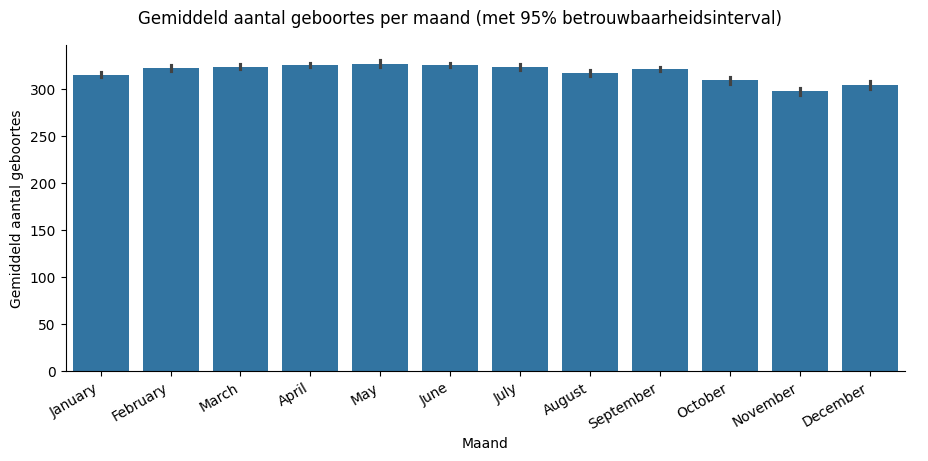

#### Vraag 3.4 (3.2) Weekdag en seizoen (4 pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Onderzoek of het effect van de dag van de week op het aantal geboortes constant is doorheen het jaar of verschilt naargelang het seizoen.

Maak één visualisatie die:
- verschillen tussen weekdagen toont
- toelaat om deze verschillen over het jaar te vergelijken
- leesbaar blijft zonder aparte grafieken per maand of weekdag



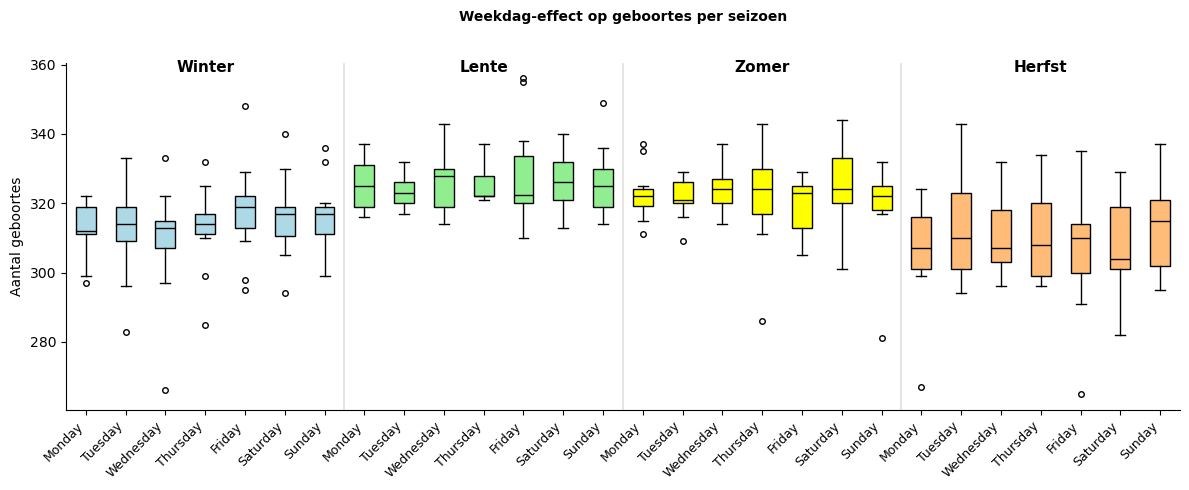

In [131]:
# WEEKDAG_EFFECT OP GEBOORTES PER SEIZOEN
# 1. Seizoenen toewijzen (maandgebaseerd)
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    if month in [3, 4, 5]: return 'Lente'
    if month in [6, 7, 8]: return 'Zomer'
    return 'Herfst'

# seizoenen toevoegen aan de reeds eerder gemaakte df_daily en category conversie
df_daily['seizoen'] = df_daily['date'].dt.month.map(get_season)
df_daily['seizoen'] = df_daily['seizoen'].astype('category')

# Instellingen voor volgorde
dagen = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
seizoenen = ['Winter', 'Lente', 'Zomer', 'Herfst']
 
# 2. Data verzamelen voor de 28 boxplots (4 seizoenen * 7 dagen)
plot_data = []
for s in seizoenen:
    for d in dagen:
        subset = df_daily[(df_daily['seizoen'] == s) & (df_daily['date'].dt.day_name() == d)]['dag_totaal']
        plot_data.append(subset)

# 3. Visualisatie
fig, ax = plt.subplots(figsize=(12, 5))

# Boxplot tekenen (strakke blauwe stijl zoals je eerdere plots)
# Boxplot tekenen
bp = ax.boxplot(plot_data, patch_artist=True, medianprops={'color': 'black'}, 
                showfliers=True, flierprops={'markersize': 4})

# Kleuren per seizoen toevoegen (optioneel, voor de intuïtieve beleving)
colors = ['lightblue', 'lightgreen', 'yellow', '#ffbb78'] # Winter, Lente, Zomer, Herfst
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(colors[i // 7])
    
# 4. Seizoensnamen centreren boven de groepen (zoals in jouw voorbeeld)
for i, seizoen in enumerate(seizoenen):
    # Het midden van elke groep van 7
    middle = (i * 7) + 4 
    ax.text(middle, ax.get_ylim()[1] * 0.99, seizoen, 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Optioneel: verticale scheidingslijn (behalve na het laatste seizoen)
    if i < 3:
        ax.axvline(x=(i + 1) * 7 + 0.5, color='gray', linestyle='-', alpha=0.2)

# 5. X-as labels (weekdagen roteren voor leesbaarheid)
weekdag_labels = dagen * 4
ax.set_xticks(range(1, 29))
ax.set_xticklabels(weekdag_labels, rotation=45, ha='right', fontsize=9)

# Afwerking
ax.set_title('Weekdag-effect op geboortes per seizoen', pad=30, fontsize=10, fontweight='bold')
ax.set_ylabel('Aantal geboortes')

clean_plot()

plt.tight_layout()
plt.show()

#### Geen weekdag-effect, wel seizoen-effect. 
#### Het toont een seizoensgebonden geboortepatroon, met hogere aantallen in de lente en zomer en lagere aantallen in de herfst.
De verschillen tussen weekdagen zijn klein en onstabiel, terwijl de seizoensverschillen duidelijk zichtbaar en veel systematischer zijn.

#### *** Comment bij Vraag 3.4
Analyse van het Weekdag-effect per Seizoen

Om te onderzoeken of de variatie in geboortes doorheen de week constant blijft of seizoensgebonden is, zijn de dagtotalen gegroepeerd per seizoen en weekdag. De boxplots tonen de centrale tendens (mediaan), de spreiding en uitschieters.

Observaties:

Seizoensgebonden Volume: Er is een duidelijke verschuiving in het basisniveau zichtbaar. De Lente en Zomer vertonen over het algemeen hogere medianen vergeleken met de Herfst, waar de geboortecijfers merkbaar dalen en de spreiding (de lengte van de whiskers) toeneemt.

Het Weekend-effect: In alle seizoenen zien we een subtiele 'v-vorm' of dip rond het weekend, hoewel dit effect in de Lente minder uitgesproken lijkt dan in de Winter of Herfst.

Consistentie van Variatie: De Herfst vertoont de grootste interne variabiliteit (langere boxen), wat wijst op een minder voorspelbaar patroon in die periode. De Zomer daarentegen toont een zeer compacte verdeling, wat duidt op een grotere stabiliteit in het dagelijkse aantal geboortes.

Methodologische verantwoording:
De keuze voor een kleurgecodeerde groepering is gemaakt voor een verbeterde intuïtieve beleving. Door elk seizoen een eigen kleuridentiteit te geven, wordt de cognitieve belasting verlaagd: de kijker herkent direct de macro-trend (seizoen) voordat hij overgaat tot de micro-analyse (weekdag). De verticale scheidingslijnen dienen als visueel anker om de vergelijking tussen de vier kwadranten van het jaar te vergemakkelijken.

The strongest seasonal difference is not only in the level of births, but also in the amount of irregular/extreme days.

Winter has by far the most outliers, so winter shows the most exceptional daily values.

Autumn has the fewest outliers, so autumn is relatively less extreme in that sense.

Spring has only a few outliers, and they are mainly high outliers.

Summer is in between.

1.Season matters more than weekday

2.Winter is the most irregular season

3.There is no stable weekday pattern repeated across all seasons

In [ ]:
#### gemini conclusion
Het Verborgen Patroon: "De Weekend-Paradox per Seizoen"Wanneer we naar de boxplot en de summary_df kijken, zien we een fenomeen dat verder gaat dan alleen "er worden meer baby's geboren in de zomer".  
Het werkelijke verborgen patroon zit in de stabiliteit van de ziekenhuisplanning versus natuurlijke variatie.  
1. De "Weekend-Dip" is niet overal gelijkIn de Herfst zien we in je data dat de mediaan op zondag ($315$) hoger ligt dan op zaterdag ($304$). Dit is een afwijking van het standaardpatroon waarbij het hele weekend meestal lager scoort.Verklaring: Dit suggereert dat in drukke periodes (zoals de nazomer/herfst-piek) de "natuurlijke" bevallingen de overhand nemen op de geplande bevallingen (keizersnedes/inleidingen), die meestal op weekdagen plaatsvinden.
2. Lente-Stabiliteit (De "Vlakke" Boxplots)Kijk naar de boxplots van de Lente. De boxen zijn opvallend compact en de medianen liggen zeer dicht bij elkaar (tussen $322$ en $328$).Het Patroon: In de lente is het geboorteproces het meest "voorspelbaar". Er is weinig spreiding tussen de dagen. Dit duidt op een periode waarin de zorgvraag zeer constant is, wat ideaal is voor ziekenhuisbezetting.
3. De "Zomer-Uitschieters" op donderdag en vrijdagIn de Zomer zien we bij de vrijdag en donderdag een grotere spreiding ($std$ van $14.07$ op donderdag).Het Patroon: Dit onthult vaak het effect van geplande inleidingen voor het weekend. Omdat de zomer een piekperiode is, proberen ziekenhuizen de toestroom te reguleren door meer bevallingen in te plannen net vóór het weekend, wat leidt tot grotere fluctuaties op die specifieke dagen.
4. De Winter-Spreiding op woensdagIn de Winter zien we op woensdag de grootste standaarddeviatie ($15.77$) en een zeer lage $min$ waarde ($266$).Het Patroon: Dit duidt op de invloed van feestdagen (Kerst/Nieuwjaar). Feestdagen vallen elk jaar op een andere weekdag, maar zorgen voor een enorme daling in geplande bevallingen. Dit trekt de onderkant van de boxplot naar beneden en vergroot de spreiding "kunstmatig".

Hoe je dit uitlegt in je opdracht.  
Je kunt het als volgt verwoorden om indruk te maken op de docent:  
"De visualisatie onthult dat de menselijke biologie (natuurlijke bevallingen) botst met de medische logistiek (geplande inleidingen).  
In de Lente zien we een harmonieus patroon met weinig spreiding.  
Echter, in de Herfst en Zomer zien we dat de spreiding op donderdag en vrijdag toeneemt.  
Dit onthult een verborgen patroon van interventie-sturing: ziekenhuizen proberen de piekdrukte te spreiden door bevallingen vaker aan het einde van de werkweek in te plannen, wat leidt tot grotere variabiliteit op die dagen."

In [ ]:
summary_df = (
    df_daily2
    .groupby(['seizoen', 'weekdag'], observed=True)['dag_totaal']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max','sum'])
    .reset_index()
)
print(len(summary_df))
# Convert to categorical with specified order
summary_df['seizoen'] = pd.Categorical(summary_df['seizoen'], categories=seizoenen, ordered=True)
summary_df['weekdag'] = pd.Categorical(summary_df['weekdag'], categories=dagen, ordered=True)

# Sort by both columns
summary_df = summary_df.sort_values(['seizoen', 'weekdag'])
summary_df

#### VoorbeeldPlot Vraag 3.4(3.2)

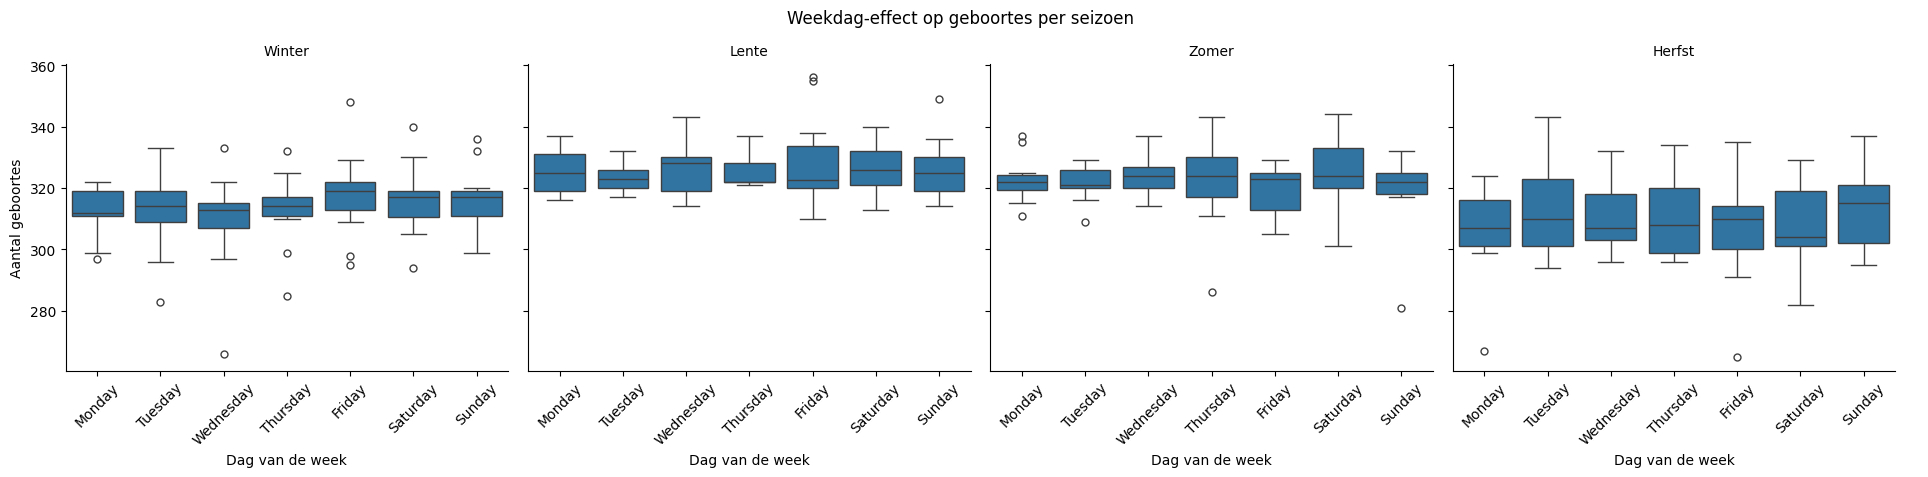

## Stap 3: Onderzoeksvragen


### Onderzoek 1: Unisex namen


#### Vraag 1.1 (3pnt)
Je wil namen identificeren die zowel bij jongens als bij meisjes voorkomen.
Construeer een tabel `df_name_gender` met exact één rij per naam, waarin je het totaal aantal geboortes voor jongens, voor meisjes en in totaal opneemt.

Rapporteer het aantal namen dat bij beide geslachten voorkomt en geef voor deze groep telkens de drie namen met het hoogste aantal jongensgeboortes, meisjesgeboortes en totale geboortes. Licht kort toe of en waarom je zeldzame namen al dan niet meeneemt in de analyse.


In [132]:
# 1. Groepeer en kantel de tabel (unstack)
# Na de unstack worden 'Mannelijk' en 'Vrouwelijk' de namen van de kolommen
df_name_gender = df_births_clean.groupby(['naam', 'geslacht'], observed = True).size().unstack(fill_value=0)
 
# 2. Totaal berekenen
df_name_gender['totaal'] = df_name_gender['Vrouwelijk'] + df_name_gender['Mannelijk']

# 3. Filteren op namen die bij BEIDE geslachten voorkomen (Mutual)
# Een naam is mutual als zowel de kolom 'Vrouwelijk' als 'Mannelijk' groter is dan 0
df_unisex = df_name_gender[(df_name_gender['Vrouwelijk'] > 0) & (df_name_gender['Mannelijk'] > 0)]
display(df_unisex.sort_values('totaal', ascending=False).head(5))

# 4. Resultaten tonen
mn  = df_unisex[['Mannelijk']].nlargest(1, 'Mannelijk').index[0]
vr = df_unisex[['Vrouwelijk']].nlargest(1, 'Vrouwelijk').index[0]
mut = df_unisex.nlargest(1, 'totaal').index[0]

print(f"{len(df_unisex)} unisex namen")
print(f"Populairse unisex naam bij de mannen: {mn}")
print(f"Populairse unisex naam bij de vrouwen: {vr}")
print(f"Populairse unisex naam in het algemeen: {mut}")

geslacht,Mannelijk,Vrouwelijk,totaal
naam,,,
Dominique,160,229,389
Maxime,200,6,206
Robin,181,8,189
Claude,165,7,172
José,140,29,169


75 unisex namen
Populairse unisex naam bij de mannen: Maxime
Populairse unisex naam bij de vrouwen: Dominique
Populairse unisex naam in het algemeen: Dominique


#### *** Comment bij Vraag 1.1
**Argumentatie voor behoud zeldzame namen:**:  
-Door een kunstmatige ondergrens te trekken (bijv. "minimaal 5 geboortes"),  
loop je het risico om opkomende genderneutrale trends of zeldzame culturele namen te missen.

**Risico-analyse:**  
-Er blijft een risico dat incidentele typefouten bij de registratie (een 'M' invullen waar een 'V' hoort) een naam onterecht als unisex bestempelen.  


#### VoorbeeldResult Vraag 1.1

Populairse unisex naam bij de mannen: Maxime
Populairse unisex naam bij de vrouwen: Dominique
Populairse unisex naam in het algemeen: Dominique


#### Vraag 1.2 (2 pnt)

Niet alle namen die bij beide geslachten voorkomen, zijn evenwichtig verdeeld. In deze oefening beschouwen we een naam als “echt unisex” wanneer het aantal geboortes bij het ene geslacht niet meer dan 50% hoger ligt dan bij het andere. Concreet geldt voor een naam met `x` mannen en `y` vrouwen dat deze als echt unisex wordt beschouwd wanneer `x <= 1.5 * y` en `y <= 1.5 * x`.

Pas deze definitie toe op je unisex dataset en construeer een DataFrame `df_real_unisex` dat uitsluitend deze echte unisex namen bevat.

Beantwoord vervolgens opnieuw de drie vragen uit de vorige oefening voor deze dataset.


In [133]:
# ECHTE UNISEX NAMEN

# Voorwaarden
conditie_m = df_unisex['Mannelijk'] <= 1.5 * df_unisex['Vrouwelijk']
conditie_v = df_unisex['Vrouwelijk'] <= 1.5 * df_unisex['Mannelijk']

# Maak de nieuwe DataFrame df_real_unisex
df_real_unisex = df_unisex[conditie_m & conditie_v].copy()
print(f"Aantal echt unisex namen: {len(df_real_unisex)}")

real_m = df_real_unisex.nlargest(1, 'Mannelijk').index[0]
real_v = df_real_unisex.nlargest(1, 'Vrouwelijk').index[0]
real_mut = df_real_unisex.nlargest(1, 'totaal').index[0]

print(f"Populairse echte unisex naam bij de mannen: {real_m} ")
print(f"Populairse echte unisex naam bij de vrouwen: {real_v} ")
print(f"Populairse echte unisex naam in het algemeen: {real_mut}")

Aantal echt unisex namen: 15
Populairse echte unisex naam bij de mannen: Dominique 
Populairse echte unisex naam bij de vrouwen: Dominique 
Populairse echte unisex naam in het algemeen: Dominique


#### VoorbeeldResult Vraag 1.2

Populairse echte unisex naam bij de mannen: Dominique
Populairse echte unisex naam bij de vrouwen: Dominique
Populairse echte unisex naam in het algemeen: Dominique


#### Vraag 1.3 (1 pnt)
Ga na of echte unisex namen relatief populairder zijn bij mannen of bij vrouwen, of dat de populariteit tussen beide geslachten vergelijkbaar is. Hiervoor kan je vertrekken van het percentage mannen en vrouwen dat een echte unisex naam draagt.

populatie_m: 58202
populatie_v: 57191
mannen met unisex naam: 231
vrouwen met unisex naam: 287
percenage mannen met unisex naam: 0.4%
percenage vrouwen met unisex naam: 0.5%



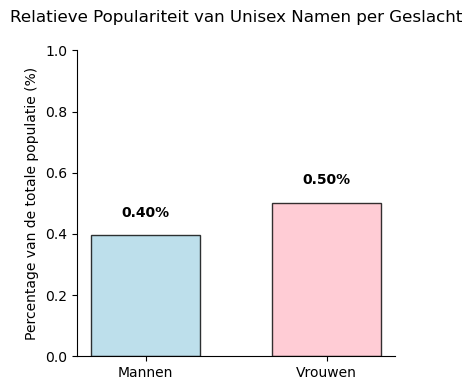

In [134]:
#POPULARITEIT REAL UNISEX NAMEN

# 1. Data voorbereiden (Berekening)

# m/v populatie
pop_m = len(df_births_clean[df_births_clean['geslacht'] == 'Mannelijk'])
pop_v = len(df_births_clean[df_births_clean['geslacht'] == 'Vrouwelijk'])

# echte unisex namen m/v
real_unisex_m = df_real_unisex['Mannelijk'].sum()
real_unisex_v = df_real_unisex['Vrouwelijk'].sum()

# Percentages berekenen
perc_m = (real_unisex_m / pop_m) * 100
perc_v = (real_unisex_v / pop_v) * 100

# Alles printen
print(f"populatie_m: {pop_m}")
print(f"populatie_v: {pop_v}")

print(f"mannen met unisex naam: {real_unisex_m}")
print(f"vrouwen met unisex naam: {real_unisex_v}")

print(f"percenage mannen met unisex naam: {perc_m:.1f}%")
print(f"percenage vrouwen met unisex naam: {perc_v:.1f}%\n")

# 2. Visualisatie
labels = ['Mannen', 'Vrouwen']
percentages = [perc_m, perc_v]
colors = ['lightblue', 'pink'] # doopsuierkleuren 

fig, ax = plt.subplots(figsize=(4, 4))

bars = ax.bar(labels, percentages, color=colors, width=0.6, edgecolor='black', alpha=0.8)

# Waarden bovenop de bars zetten
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')

# Styling
ax.set_title('Relatieve Populariteit van Unisex Namen per Geslacht', pad=20) #, fontweight='bold')
ax.set_ylabel('Percentage van de totale populatie (%)')
ax.set_ylim(0, max(percentages) + 0.5) # Ruimte voor de tekst labels

# Verwijder randen voor een moderne look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### VoorbeeldResult Vraag 1.3

Percentage mannen met unisex naam: 0.4%
Percentage vrouwen met unisex naam: 0.5%


#### Vraag 1.4 (2 pnt)

Maak een visualizatie die alle echte unisex namen toont en de relatieve voorkomens bij mannen en vrouwen.

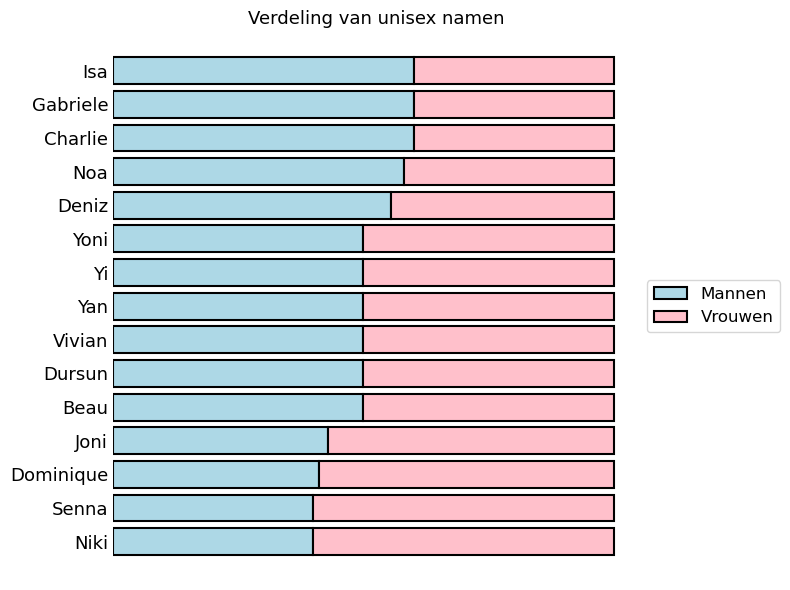

In [135]:
# VERDELING REAL UNISEX NAMES


# --- STAP 1: BEREKEN RELATIEVE VOORKOMENS ---

df_relatief = df_real_unisex.copy()

# Bereken de percentages
df_relatief['Mannen_Pct'] = (df_relatief['Mannelijk'] / df_relatief['totaal']) * 100
df_relatief['Vrouwen_Pct'] = (df_relatief['Vrouwelijk'] / df_relatief['totaal']) * 100

# Sorteer de dataset op 'Mannen_Pct' om de volgorde in de afbeelding te krijgen.
df_sorted = df_relatief.sort_values(by='Mannen_Pct', ascending=True)

# --- STAP 2: MAAK DE VISUALISATIE ---
# Gestapelde staafdiagram.

# Definieer de namen en de percentages voor de x-as
namen = df_sorted.index
mannen_pct = df_sorted['Mannen_Pct']
vrouwen_pct = df_sorted['Vrouwen_Pct']

# Maak het figuur en de assen objecten
fig, ax = plt.subplots(figsize=(8, 6))

# Maak de blauwe balken voor de mannen
balken_mannen = ax.barh(namen, mannen_pct, color='lightblue', label='Mannen', edgecolor='black', linewidth =1.5)

# Maak de roze balken voor de vrouwen, 'gestapeld' op de mannen
# opschuiven' met 'left=mannen_pct'
balken_vrouwen = ax.barh(namen, vrouwen_pct, left=mannen_pct, color='pink', label='Vrouwen', edgecolor='black', linewidth =1.5)

# --- STAP 3: STYLING & FINETUNING ---

# Titel en de labels in
ax.set_title('Verdeling van unisex namen', fontsize=13)

# Verwijder alle as-ticks en -labels voor de x- en y-as
ax.set_xticks([])
# De namen staan al op de y-as, maar we verbergen de tics
ax.tick_params(axis='y', which='both', length=0, labelsize=13)

# Voeg de legenda toe aan de rechterkant (precies zoals in de afbeelding)
# De locatie (loc) en bbox_to_anchor zorgen voor de positionering.
ax.legend(handles=[balken_mannen[0], balken_vrouwen[0]], labels=['Mannen', 'Vrouwen'],
          loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
clean_plot(0)

# Toon de grafiek
plt.tight_layout()
plt.show()


#### VoorbeeldPlot Vraag 1.4

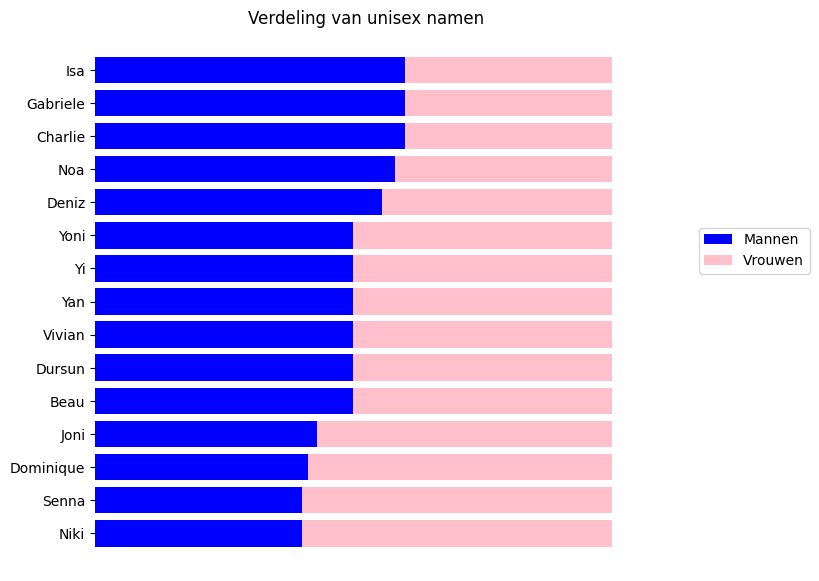

In [ ]:
df_real_unisex

### Onderzoek 2: de accuraatheid van de geschatte bevallingsdatum


### Vraag 2.1 Evolutie vergelijken (3pnt)

Maak één figuur waarin je het totale aantal effectieve geboortes per dag en het totale aantal verwachte geboortes per dag samen weergeeft over de tijd.

Zorg ervoor dat beide reeksen op een eerlijke en vergelijkbare manier worden getoond.


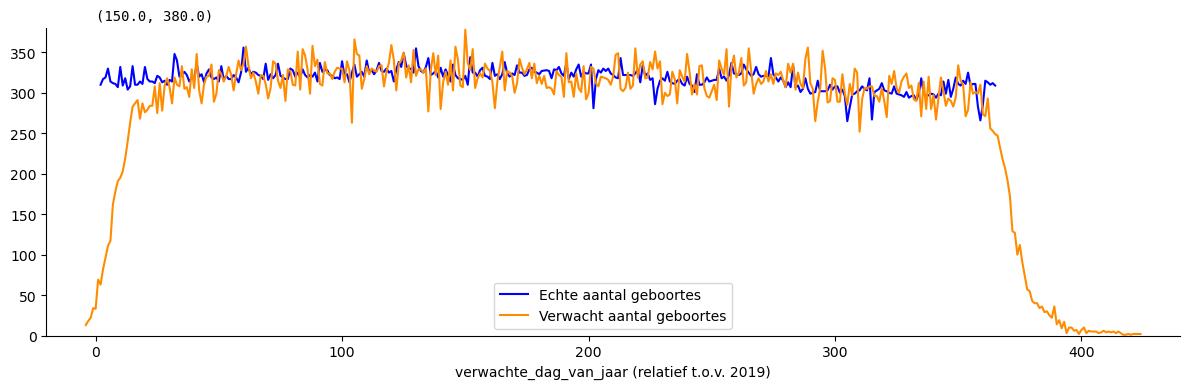

In [217]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Voorbereiden van de data
# We definiëren de referentiedatum (Start van het focusjaar)
ref_date = pd.Timestamp('2019-01-01')

# Verwachte geboortes omzetten naar de nieuwe schaal
df_expected_data = df_births_clean.copy()

# Bereken het verschil in dagen. 
# (datum - ref) geeft 0 voor 1 jan, dus we doen + 1 om 1-based te werken voor 2019.
df_expected_data['relatieve_dag'] = (df_expected_data['verwachte datum'] - ref_date).dt.days + 1
df_expected = df_expected_data.groupby('relatieve_dag').size()

# Effectieve geboortes:
# Al gegroepeerd op 'dag_van_jaar' (1-365), 
df_effective = df_births_clean.groupby('dag_van_jaar').size()

# 2. De figuur maken
plt.figure(figsize=(12, 4))

# Plot de effectieve geboortes (Blauw)
plt.plot(df_effective.index, df_effective.values, 
         color='blue', label='Echte aantal geboortes')

# Plot de verwachte geboortes (Oranje)
# De index bevat nu negatieve getallen (2018) en getallen boven 365 (2020)
plt.plot(df_expected.index, df_expected.values, 
         color='darkorange', label='Verwacht aantal geboortes')

# 3. Styling
plt.xlabel('verwachte_dag_van_jaar (relatief t.o.v. 2019)')
plt.xlim(-20, 440) 
plt.ylim(0, 380)

clean_plot() # Je custom functie (verwijdert top/right)

plt.legend()
plt.text(0, 390, '(150.0, 380.0)', fontsize=10, family='monospace')

plt.tight_layout()
plt.show()

#### VoorbeeldPlot Vraag 2.1

(150.0, 380.0)

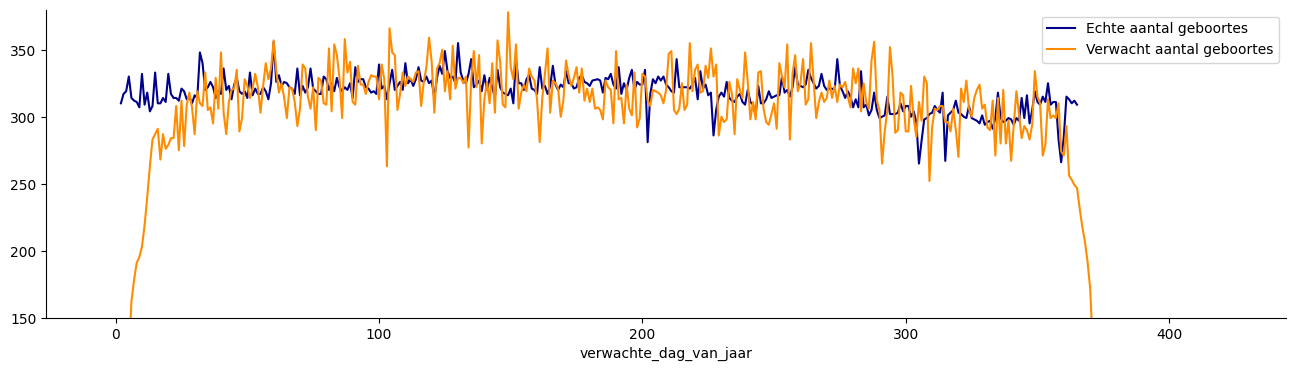

In [ ]:
AFWIJKEND -1DAG: VERWACHTE AANTAL OP 2019-01-01 = DAG 0

#### *** Comment Vraag 2.1

In [167]:
# NAUWKEURIGHEIDSCHECK DF_EXPECTED_DATA['VERWACHTE DATUM']

df1= df_expected_data[(df_expected_data['verwachte datum']=='2018-12-31')].head(1)#expect:0
df2 = df_expected_data[(df_expected_data['verwachte datum']=='2019-01-01')].head(1)#expect:1
df3 = df_expected_data[(df_expected_data['verwachte datum']=='2019-12-31')].head(1)#expect:365
df4 = df_expected_data[(df_expected_data['verwachte datum']=='2020-01-01')].head(1)#expect:366
df_combined = pd.concat([df1, df2, df3, df4])
df_combined

,gemeente,naam,geslacht,verwachte datum,date,dag_van_jaar,relatieve_dag
3704,Overijse,Karel,Mannelijk,2018-12-31,2019-01-02,2,0
3697,Charleroi,Arlette,Vrouwelijk,2019-01-01,2019-01-02,2,1
20579,Rijkevorsel,Frieda,Vrouwelijk,2019-12-31,2019-11-12,316,365
20938,Oudenaarde,Erik,Mannelijk,2020-01-01,2019-11-13,317,366


In [ ]:
df_effective.head(10)

#### Vraag 2.2 (1 pnt)
De figuur vertoont aan het begin en het einde van het jaar een afwijkend patroon. Beschrijf kort waarom dit gebeurt en noteer je verklaring in een comment

In [ ]:
# BEGIN/EIND JAAR INZOOMEN

df_jaar = df_expected_data.groupby(['relatieve_dag', 'verwachte datum']).size().reset_index(name='aantal')
df_kop_staart = pd.concat([df_jaar.head(10),df_jaar.tail(62)])
df_jaar


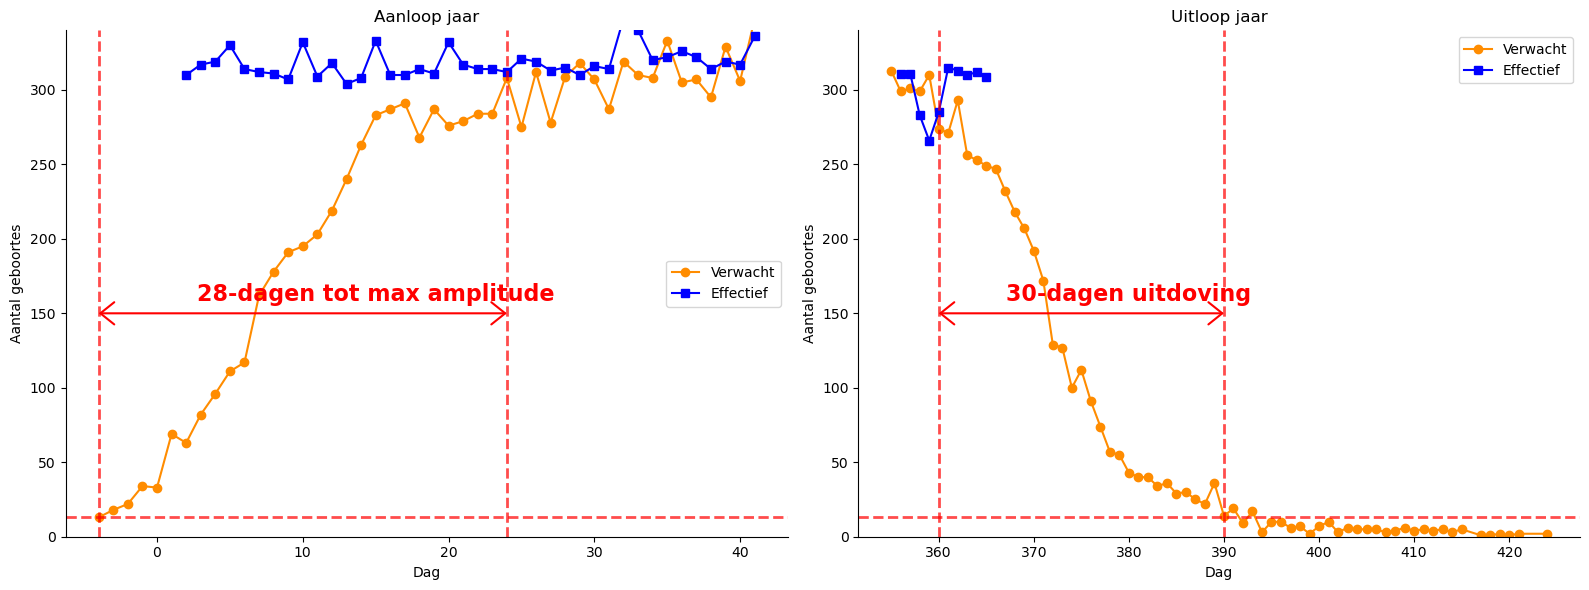

In [270]:
#PLOT BEGIN_EIND INZOOMEN


df_jaar = df_expected_data.groupby(['relatieve_dag', 'verwachte datum']).size().reset_index(name='aantal')

# 1. Voorbereiden van de subplots (1 rij, 2 kolommen)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2.--- PLOT 1: De Aanloop ---
d1_exp = df_jaar.head(46)
d1_eff = df_effective.head(40)

# 2a. Data plot
# Curve 1 (Verwacht) - Gebruik kolommen uit DataFrame
ax1.plot(d1_exp['relatieve_dag'], d1_exp['aantal'], 
         color='darkorange', marker='o', label='Verwacht')
# Curve 2 (Effectief) - Gebruik index en values van de Series
ax1.plot(d1_eff.index, d1_eff.values, 
         color='blue', marker='s', label='Effectief')

# 2b. Hulplijnen
# Voeg horizontale stippellijn toe aan Plot 1
ax1.axhline(y=13, color='red', linestyle='--', linewidth=2, alpha=0.7)#, label='y = 13')
# Voeg verticale stippellijnnen toe aan Plot 1
ax1.axvline(x=-4, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax1.axvline(x=24, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Bereken de breedte van het interval
start_x = -4
end_x = 24
breedte1 = abs(end_x - start_x) # 28 dagen

# De dubbele pijl met tekst ("x-dagen") toevoegen
ax1.annotate(
    '',                      # Geen tekst direct bij het ankerpunt
    xy=(start_x, 150),          # Startpunt van de pijl (linker verticale lijn, y=150)
    xytext=(end_x, 150),        # Eindpunt van de pijl (rechter verticale lijn, y=150)
    arrowprops=dict(
        arrowstyle='<->, head_width=0.8, head_length=1.0',      # Dubbele pijlpunt
        color='red',         # Kleur van de pijl
        linewidth=1.5,
        shrinkA=0, shrinkB=0   # Voorkomt dat de pijl "krimpt" bij het ankerpunt
    )
)

#  Het tekstlabel "x-dagen" boven het midden van de pijl plaatsen
midden_x = (start_x + end_x) / 2 + 5
# Plaats de tekst iets boven y=5 (bijv. y=155)
ax1.text(midden_x, 155, f'{breedte1}-dagen tot max amplitude', 
         color='red', fontsize=16, fontweight='bold', ha='center', va='bottom')

ax1.set_ylim(0,340)
ax1.set_title("Aanloop jaar")
ax1.legend()

# 3.--- PLOT 2: De Uitloop ---
d2_exp = df_jaar.tail(67)
d2_eff = df_effective.tail(10)

# 3a. Data plot 
# Curve 1 (Verwacht)
ax2.plot(d2_exp['relatieve_dag'], d2_exp['aantal'], 
         color='darkorange', marker='o',label='Verwacht')
# Curve 2 (Effectief)
ax2.plot(d2_eff.index, d2_eff.values, 
         color='blue', marker='s',label='Effectief')

# 3b. Hulplijnen
# Voeg horizontale stippellijne toe aan Plot 2
ax2.axhline(y=13, color='red', linestyle='--', linewidth=2, alpha=0.7)#, label='y = 13')
# Voeg verticale stippellijnnen toe aan Plot 1
ax2.axvline(x=360, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax2.axvline(x=390, color='red', linestyle='--', linewidth=2, alpha=0.7)

# Bereken de breedte van het interval
start_x = 360
end_x = 390
breedte2 = abs(end_x - start_x) # 28 dagen

# De dubbele pijl met tekst ("x-dagen") toevoegen
ax2.annotate(
    '',                      # Geen tekst direct bij het ankerpunt
    xy=(start_x, 150),          # Startpunt van de pijl (linker verticale lijn, y=150)
    xytext=(end_x, 150),        # Eindpunt van de pijl (rechter verticale lijn, y=150)
    arrowprops=dict(
        arrowstyle='<->, head_width=0.8, head_length=1.0',      # Dubbele pijlpunt
        color='red',         # Kleur van de pijl
        linewidth=1.5,
        shrinkA=0, shrinkB=0   # Voorkomt dat de pijl "krimpt" bij het ankerpunt
    )
)

# Tekstlabel "x-dagen" boven het midden van de pijl plaatsen
midden_x = (start_x + end_x) / 2 + 5
# Plaats de tekst iets boven y=150 (bijv. y=155)
ax2.text(midden_x, 155, f'{breedte2}-dagen uitdoving', 
         color='red', fontsize=16, fontweight='bold', ha='center', va='bottom')



#ax2.set_ylim(0,340)
ax2.set_title("Uitloop jaar")
ax2.legend()

# --- Globale styling ---
for ax in [ax1, ax2]:
    ax.set_xlabel('Dag')
    ax.set_ylabel('Aantal geboortes')
    # Hier kun je je eigen clean_plot() logica toepassen op de specifieke ax:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0,340)


plt.tight_layout()
plt.show()

#### *** Comment Vraag 2.2  

-De dagen na 2019-12-31 zijn geprojecteerde dagen 'gemaakt' tijdens het actieve jaar.
De projecties van 'verwachte datum' stoppen na 31december 2019 er komen geen nieuwe bij.  
Hoe later in de toekomst hoe kleiner de verwachtingswaarde ->**uitdoving**.  
In een real-world case zoudens de max amplitude van 'verwachte datum'  **samenstellingen van normaal verdelingen** zijn die elkaar overlappen (wss ook in deze sim).  
De uitloop lijkt bijna een **halve normaal verdeling**.  
-De aanloop tot max amplitude loopt over dezelfde tijdspanne.  
De dataset is een simulatie, er zijn in het begin te weinig voorspellingen.  
-Het is discutabel om wegens deze elementen de eerste en mogelijk de laatste maand er uit te laten.  
In de volgende plot van Vraag 2.3 veranderd dit niets aan de vorm. (amplitude*(10/12)). 

In [ ]:
# Aan het begin van het jaar ontbreken verwachte geboortes waarvan de verwachte datum
# nog in 2018 ligt. Aan het einde van het jaar gebeurt hetzelfde voor verwachte datums
# in 2020. Daardoor zie je aan beide randen een kunstmatig afwijkend patroon.
# Dit is dus vooral een rand- of afkappingseffect van de dataset.

### Vraag 2.3 (3 pnt)

Voor het jaar 2019 wil je analyseren hoe vroeg baby’s effectief geboren worden ten opzichte van hun verwachte geboortedatum.

Definieer een foutmaat die het verschil uitdrukt tussen de effectieve en de verwachte geboortedag, waarbij positieve waarden overeenkomen met een geboorte vóór de verwachte datum. Beperk je analyse tot geboortes die effectief te vroeg plaatsvinden en visualiseer de verdeling van deze foutmaat voor 2019 in een histogram. Kies het aantal bins expliciet en motiveer kort waarom deze keuze geschikt is.

Duid in het histogram zowel de mediaan als het 90e percentiel van het aantal dagen te vroeg expliciet aan.


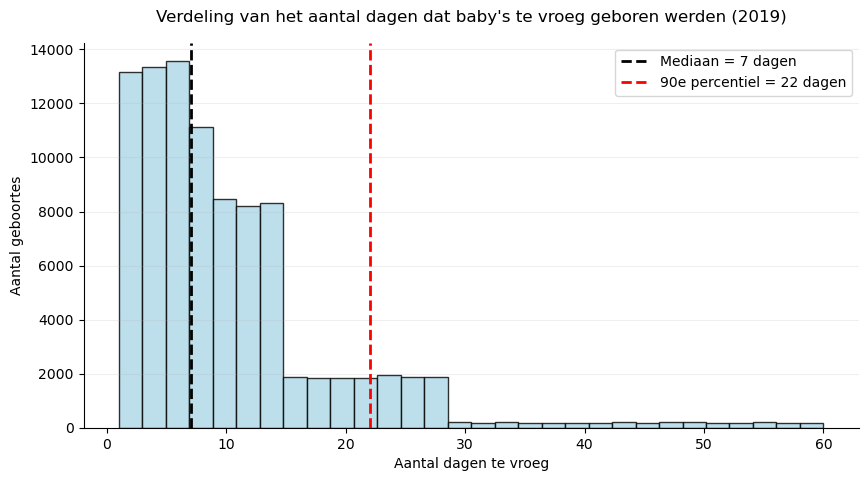

In [275]:
import matplotlib.pyplot as plt
import pandas as pd

# --- VRAAG 2.3 ---

# 1. Definiëren van de foutmaat
# Positieve waarden = geboorte VÓÓR de verwachte datum
df_expected_data['foutmaat'] = (pd.to_datetime(df_expected_data['verwachte datum']) - 
                               pd.to_datetime(df_expected_data['date'])).dt.days

# 2. Beperken tot geboortes die effectief TE VROEG plaatsvinden (> 0)
df_vroeg = df_expected_data[df_expected_data['foutmaat'] > 0].copy()

# 3. Statistieken berekenen
mediaan_vroeg = df_vroeg['foutmaat'].median()
p90_vroeg = df_vroeg['foutmaat'].quantile(0.90)

# 4. Visualisatie
plt.figure(figsize=(10, 5))

# MOTIVATIE BINS: 
# Er is gekozen voor 30 bins over een bereik van ongeveer 60 dagen. 
# Dit creëert intervallen van 2 dagen per bin. Dit is breed genoeg om 
# dagelijkse ruis te onderdrukken, maar smal genoeg om de duidelijke 
# afname en de 'plateaus' in vroeggeboortes nauwkeurig weer te geven.
plt.hist(df_vroeg['foutmaat'], bins=30, color='lightblue', edgecolor='black', alpha=0.8) #color='#5D99C6'

# 5. Indicatoren toevoegen (Mediaan en 90e percentiel)
plt.axvline(mediaan_vroeg, color='black', linestyle='--', linewidth=2, 
            label=f'Mediaan = {mediaan_vroeg:.0f} dagen')
plt.axvline(p90_vroeg, color='red', linestyle='--', linewidth=2, 
            label=f'90e percentiel = {p90_vroeg:.0f} dagen')

# 6. Afwerking
plt.title("Verdeling van het aantal dagen dat baby's te vroeg geboren werden (2019)", pad=15)
plt.xlabel("Aantal dagen te vroeg")
plt.ylabel("Aantal geboortes")
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='-', alpha=0.2)

# Optioneel: je eigen clean_plot() functie oproepen
if 'clean_plot' in globals():
    clean_plot()

plt.show()

# VERKLARING (Commentaar voor Vraag 2.3):
# De foutmaat (Verwacht - Effectief) geeft direct aan hoeveel dagen een baby 'te vroeg' is.
# De mediaan van 7 dagen toont aan dat de helft van de te vroege baby's binnen een week 
# van de datum komt. Het 90e percentiel bij 22 dagen markeert de grens voor 
# medisch significante vroeggeboortes (meer dan 3 weken te vroeg).

#### VoorbeeldPlot Vraag 2.3

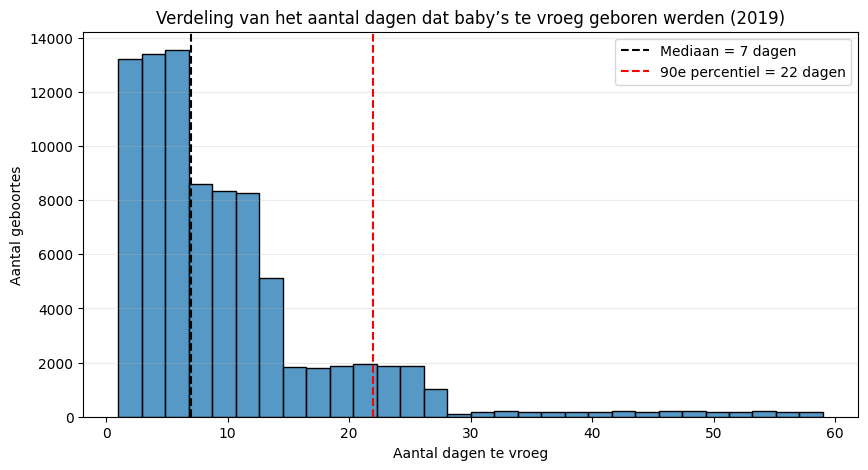

### Vraag 2.4 (4 pnt)

Voor het jaar 2019 wil je nagaan hoe goed de verwachte geboortedag overeenkomt met de effectieve geboortedag, maar je wil dit nu enkel doen voor de acht gemeenten met het hoogste aantal geboortes.

Bepaal eerst welke acht gemeenten in 2019 de meeste geboortes tellen. Visualiseer vervolgens, voor deze acht gemeenten, de relatie tussen de effectieve dag van het jaar en de verwachte dag van het jaar in een scatterplot per gemeente, zodat je kan vergelijken of de accuraatheid verschilt tussen gemeenten.

Gebruik in alle deelplots dezelfde schaal op beide assen en voeg een referentielijn toe die een perfecte schatting voorstelt.


In [ ]:
df_expected_data.head(1)

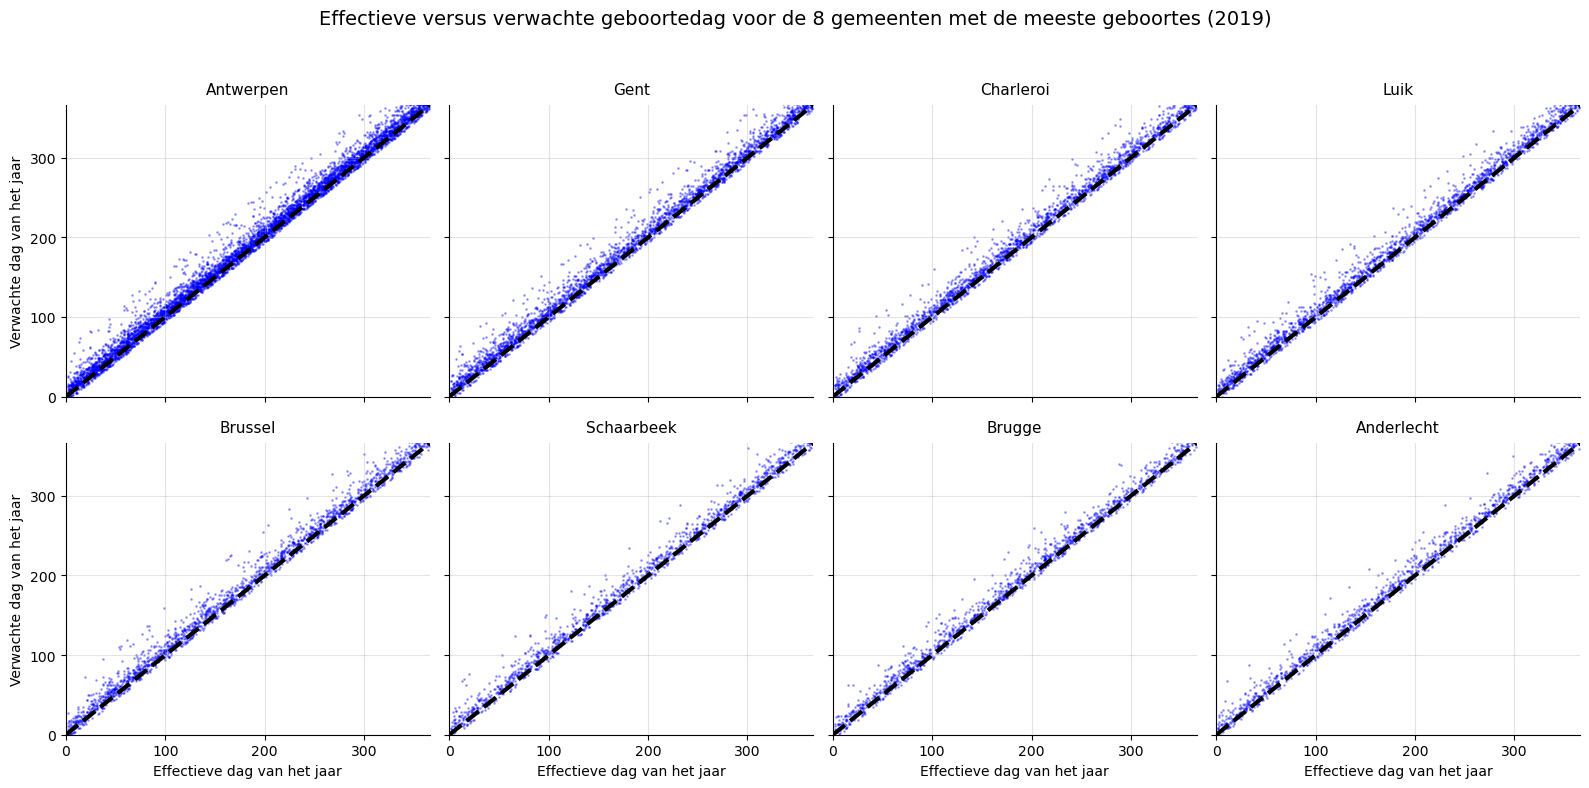

In [296]:
# --- PLOT TOP 8 GEMEENTEN, REFERENTIELIJN  Y = X

# --- Bepaal de 'Top 8' gemeenten ---
top_gemeenten = df_expected_data.groupby('gemeente', observed = True).size().nlargest(8).index.tolist()

# Maak een gefilterd DataFrame voor enkel deze gemeenten
df_top8 = df_expected_data[df_expected_data['gemeente'].isin(top_gemeenten)].copy()
#print(f"Top 8 Gemeenten: {', '.join(top_gemeenten)}")
#Top 8 Gemeenten: Antwerpen, Gent, Charleroi, Luik, Brussel, Schaarbeek, Brugge, Anderlecht

# 2 rijen en 4 kolommen voor de 8 gemeenten.
# sharex=True en sharey=True => dwingt alle deelplots tot dezelfde schaal
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)

# Flatten de assen-lijst voor makkelijke iteratie (ax1..ax8 in 1 loop) 2D-> 1D simpele loop en enumerate() functie toepasbaar
axes_flat = axes.flatten()

# Definieer de gedeelde as-limieten (0-366)
as_limieten = (0, 366)

# --- Itereren door de gemeenten en plotten ---enumerate voegt er een teller(index) aan toe
for i, gemeente in enumerate(top_gemeenten):
    ax = axes_flat[i]
    
    # Filter data voor deze specifieke gemeente
    data_gemeente = df_top8[df_top8['gemeente'] == gemeente]
    
    # 1. De Scatterplot ('Wolk')
    # alpha=0.2 voor doorzichtigheid, 
    # s=1 of lager voor kleine punten om overplotting te tonen.
    ax.scatter(data_gemeente['dag_van_jaar'], data_gemeente['relatieve_dag'], 
               color='blue', 
               alpha=0.3, 
               s=1.0)
    
    # 2. De Referentielijn (y=x)
    # y=x betekent effectief_dag == verwachte_dag (Perfecte schatting).
    # Plot van 0 tot 366.
    ax.plot([as_limieten[0], as_limieten[1]], [as_limieten[0], as_limieten[1]], 
            color='black', linestyle='--', linewidth=3.0)
    
    # --- Styling van de deelplot ---
    ax.set_title(gemeente, fontsize=11, fontweight='normal', pad=8)
    
    # Zet as-limieten en as-streepjes (ticks)
    ax.set_xlim(as_limieten)
    ax.set_ylim(as_limieten)
    ax.set_xticks([0, 100, 200, 300]) # Zie voorbeeld
    ax.set_yticks([0, 100, 200, 300]) 
    
    # As-labels alleen aan de buitenste randen
    # Y-as label alleen voor de eerste kolom van deelplots
    if i % 4 == 0:
        ax.set_ylabel('Verwachte dag van het jaar', fontsize=10)
    # X-as label alleen voor de onderste rij van deelplots
    if i >= 4:
        ax.set_xlabel('Effectieve dag van het jaar', fontsize=10)
        
# Gebruik je clean_plot() functie of Matplotlib's tight_layout()
    if 'clean_plot' in globals():
        # Deelplot styling
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(alpha=0.35) # lichte grid toevoegen

# --- Stap G: Globale Styling van de figuur ---
fig.suptitle('Effectieve versus verwachte geboortedag voor de 8 gemeenten met de meeste geboortes (2019)', 
             fontsize=14, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ruimte voor de hoofd-titel
plt.show()

#### VoorbeeldPlots Vraag 2.4

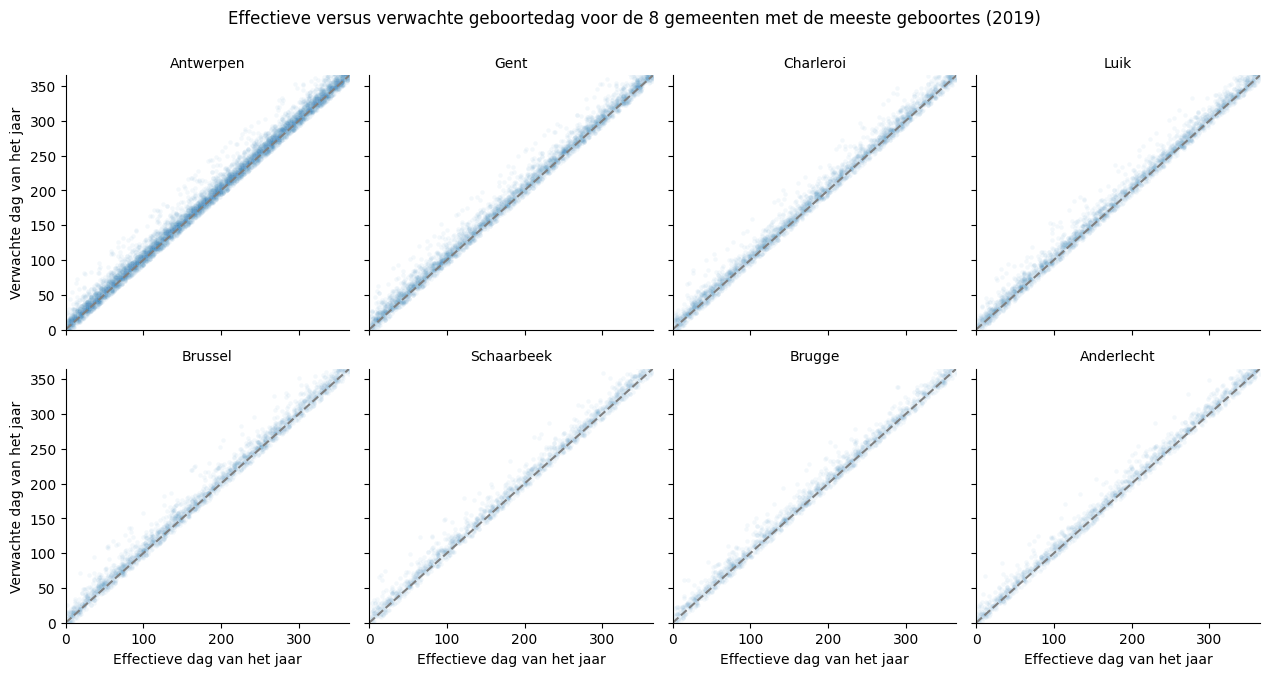

### Onderzoek 3: Aantal namen versus aantal babies

#### Vraag 3.1

Wanneer er meer baby’s geboren worden, verwachten we ook meer verschillende namen te observeren. Bij lage aantallen geboortes lijkt het aannemelijk dat dit verband ongeveer lineair is, maar bij grotere aantallen wordt het minder vanzelfsprekend dat het aantal unieke namen in dezelfde mate blijft toenemen. We verwachten bijvoorbeeld niet dat het aantal unieke namen bij twee miljoen geboortes dubbel zo groot is als bij één miljoen geboortes.

Onderzoek op basis van deze dataset het verband tussen het aantal baby’s en het aantal unieke namen. Je krijgt geen suggestie voor een specifieke visualisatie en kiest zelf hoe je dit verband het best aantoont.

Onderbouw je antwoord met **minstens één** visualisatie en bijkomende analyse waar nodig. Probeer niet enkel te beschrijven wat je ziet, maar overtuig waarom jouw conclusie logisch is gegeven de data en waarom een lineair verband al dan niet houdbaar blijft over het volledige bereik.


#### Vraag 3.1.1

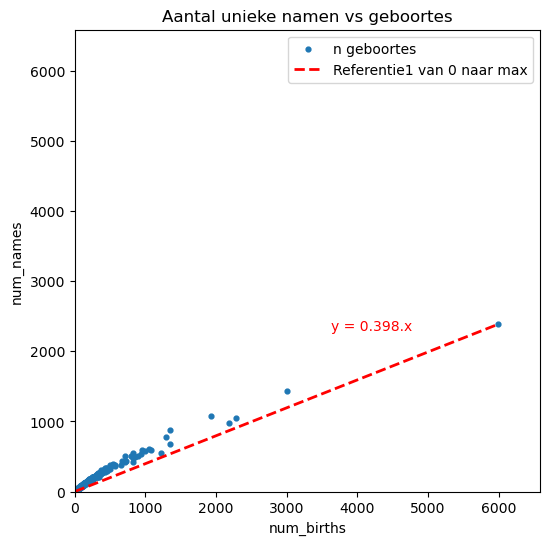

In [438]:
# VEREENVOUDIGDE PLOT: NAMES VS BIRTHS PER GEMEENTE

x = df_namen_stats['num_births']
y = df_namen_stats['num_unique_names']

max_births = df_namen_stats['num_births'].max()
max_names = df_namen_stats['num_unique_names'].max()

# Plotting 
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=12, label='n geboortes')

# teken referentie van (0,0) tot max(x,y)
plt.plot([0, max_births], [0, max_names], 
         color='red', linewidth=2, linestyle='--', 
         label='Referentie1 van 0 naar max')
# tekst slope referentie lijn y=ax
plt.text(
    0.55, 0.35,
    f"y = {max_names/max_births:.3f}.x",
    transform=plt.gca().transAxes,
    color = 'red',
    #ha="left",
    #va="top"
)

plt.title('Aantal unieke namen vs geboortes')
plt.xlabel("num_births")
plt.ylabel("num_names")
plt.legend()
plt.xlim(0, max_births*1.1)
plt.ylim(0, max_births*1.1)
plt.show()



R² WAARDEN (hoe hoger, hoe beter de fit)
Trendlijn (y = 0.464x + 47.9): R² = 0.9530
Referentielijn (y = 0.5x):     R² = 0.8894
Verschil: 0.0636

Interpretatie:
✓ De trendlijn past BETER bij de data dan y=0.5x


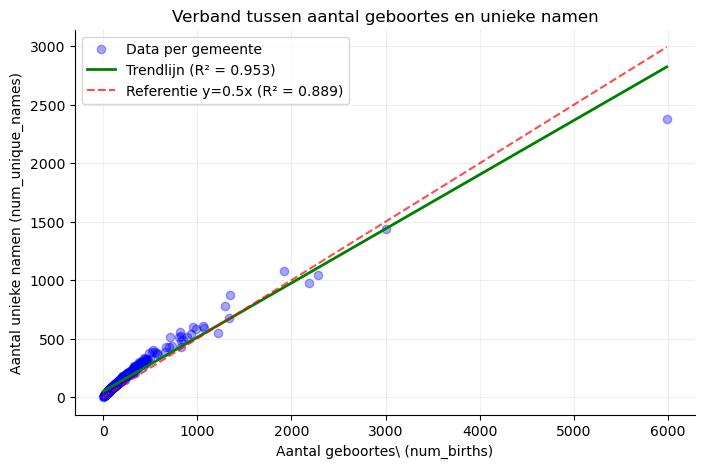

In [431]:
# AANTAL NAMEN VS AANTAL BABIES 1

# Stap A: Data voorbereiden (groepeer per gemeente of per dag/maand combinatie)
df_namen_stats = df_expected_data.groupby('gemeente', observed = True).agg(
    num_births=('naam', 'count'),
    num_unique_names=('naam', 'nunique')
).reset_index()

# Stap B: Variabelen voor gebruiksgemak
x = df_namen_stats['num_births']
y = df_namen_stats['num_unique_names']

# Stap C: Bereken trendlijn (lineaire regressie)
coef_lin = np.polyfit(x, y, 1)  # [a, b] voor y = a*x + b
y_trend = np.polyval(coef_lin, x)  # voorspelde y-waarden voor trendlijn

# Stap D: Bereken y-waarden voor referentielijn y = 0.5x
y_reference = 0.5 * x

# Stap E: Functie om R² te berekenen
def bereken_r2(y_werkelijk, y_voorspeld):
    """
    Berekent R² (determinatiecoëfficiënt)
    R² = 1 - (SS_res / SS_tot)
    """
    ss_res = np.sum((y_werkelijk - y_voorspeld) ** 2)  # residuele kwadratensom
    ss_tot = np.sum((y_werkelijk - np.mean(y_werkelijk)) ** 2)  # totale kwadratensom
    r2 = 1 - (ss_res / ss_tot)
    return r2

# Stap F: Bereken R² voor beide lijnen
r2_trendlijn = bereken_r2(y, y_trend)
r2_referentie = bereken_r2(y, y_reference)

# Stap G: Print resultaten
print("=" * 50)
print("R² WAARDEN (hoe hoger, hoe beter de fit)")
print("=" * 50)
print(f"Trendlijn (y = {coef_lin[0]:.3f}x + {coef_lin[1]:.1f}): R² = {r2_trendlijn:.4f}")
print(f"Referentielijn (y = 0.5x):     R² = {r2_referentie:.4f}")
print("=" * 50)
print(f"Verschil: {r2_trendlijn - r2_referentie:.4f}")
print("\nInterpretatie:")
if r2_trendlijn > r2_referentie:
    print("✓ De trendlijn past BETER bij de data dan y=0.5x")
else:
    print("✓ De referentielijn y=0.5x past BETER bij de data")
print("=" * 50)

# Stap H: Plot
plt.figure(figsize=(8, 5))

# Scatterplot
plt.scatter(x, y, alpha=0.35, color='blue', label='Data per gemeente')

# Trendlijn (groen)
x_line = np.linspace(x.min(), x.max(), 400)
y_line_trend = np.polyval(coef_lin, x_line)
plt.plot(x_line, y_line_trend, color='green', linewidth=2,
         label=f'Trendlijn (R² = {r2_trendlijn:.3f})')

# Referentielijn y=0.5x (rood, gestreept)
lim = max(x.max(), y.max())
plt.plot([0, lim], [0, lim/2], color='red', linestyle='--', alpha=0.7,
         label=f'Referentie y=0.5x (R² = {r2_referentie:.3f})')

plt.title('Verband tussen aantal geboortes en unieke namen')
plt.xlabel('Aantal geboortes\ (num_births)')
plt.ylabel('Aantal unieke namen (num_unique_names)')
plt.legend()
plt.grid(True, alpha=0.2)

if 'clean_plot' in globals(): 
    clean_plot()
plt.show()

Trendlijnen plotten — lineair, logaritmisch, exponentieel, macht en polynoom


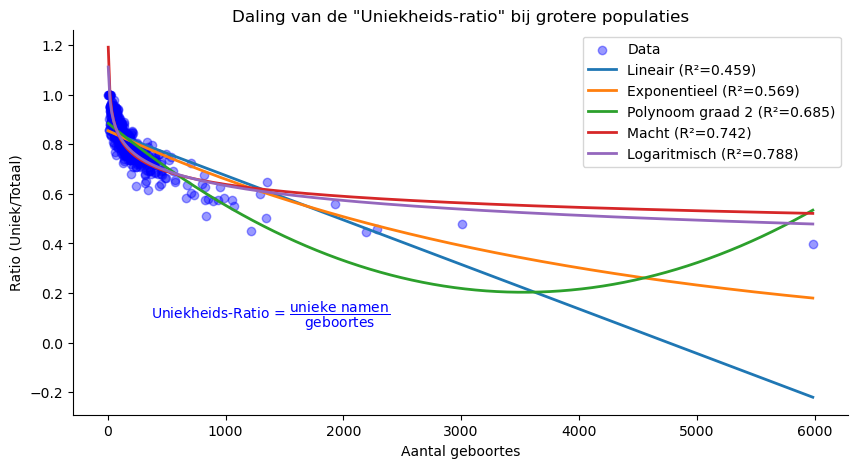

          model        r2
0  logaritmisch  0.787739
1         macht  0.741763
2    polynoom_2  0.685456
3  exponentieel  0.568524
4       lineair  0.459141
Elapsed time: 0.77 s
                            2026-03-24 15:45:15


In [421]:
# DALING UNIEKHEIDS-RATIO BIJ GROTERE POPULATIES
# R² REGRESSIE STUDIE
print("Trendlijnen plotten — lineair, logaritmisch, exponentieel, macht en polynoom")
# GPT-5.4 24/03/2026 11:00

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from time import time





def r2_score_manual(y_true, y_pred):
    # Bepaal R² manueel:
    # 1 - (som van kwadratische fouten / totale variantie)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


# X = aantal geboortes per gemeente
# df_namen_stats: groepering per gemeente
x = df_namen_stats["num_births"].to_numpy(dtype=float)

# Y = uniekheids-ratio = aantal unieke namen / aantal geboortes
y = (df_namen_stats["num_unique_names"] / df_namen_stats["num_births"]).to_numpy(dtype=float)

# Verwijder eventuele ongeldige waarden
ok = np.isfinite(x) & np.isfinite(y)
x = x[ok]
y = y[ok]

plt.figure(figsize=(10, 5))

# Teken eerst de ruwe datapunten
plt.scatter(x, y, alpha=0.4, color = 'blue', label="Data")

# Hier bewaren we per model de R²-score
resultaten = []

# ==========================================================
# 1) LINEAIR MODEL
# y = a*x + b
# ==========================================================
coef_lin = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 400) #normalisering of "equidistante herschaling"
y_line = np.polyval(coef_lin, x_line)

# Bereken R² op de oorspronkelijke punten
r2_lin = r2_score_manual(y, np.polyval(coef_lin, x))

plt.plot(x_line, y_line, linewidth=2, label=f"Lineair (R²={r2_lin:.3f})")
resultaten.append(("lineair", r2_lin))

# ==========================================================
# 2) EXPONENTIEEL MODEL
# y = a * exp(b*x)
# Hiervoor moet y > 0 zijn
# ==========================================================
mask_exp = y > 0
coef_exp = np.polyfit(x[mask_exp], np.log(y[mask_exp]), 1)
x_exp = np.linspace(x[mask_exp].min(), x[mask_exp].max(), 400)
y_exp = np.exp(coef_exp[1]) * np.exp(coef_exp[0] * x_exp)

# Voorspelde waarden op de originele punten
y_exp_fit = np.exp(coef_exp[1]) * np.exp(coef_exp[0] * x[mask_exp])
r2_exp = r2_score_manual(y[mask_exp], y_exp_fit)

plt.plot(x_exp, y_exp, linewidth=2, label=f"Exponentieel (R²={r2_exp:.3f})")
resultaten.append(("exponentieel", r2_exp))

# ==========================================================
# 3) POLYNOOM VAN GRAAD 2
# y = a*x² + b*x + c
# ==========================================================
coef_poly2 = np.polyfit(x, y, 2)
x_poly2 = np.linspace(x.min(), x.max(), 400)
y_poly2 = np.polyval(coef_poly2, x_poly2)

r2_poly2 = r2_score_manual(y, np.polyval(coef_poly2, x))

plt.plot(x_poly2, y_poly2, linewidth=2, label=f"Polynoom graad 2 (R²={r2_poly2:.3f})")
resultaten.append(("polynoom_2", r2_poly2))

# ==========================================================
# 4) MACHTSMODEL
# y = a * x^b
# Hiervoor moeten zowel x als y positief zijn
# ==========================================================
mask_pow = (x > 0) & (y > 0)
coef_pow = np.polyfit(np.log(x[mask_pow]), np.log(y[mask_pow]), 1)
x_pow = np.linspace(x[mask_pow].min(), x[mask_pow].max(), 400)
y_pow = np.exp(coef_pow[1]) * x_pow ** coef_pow[0]

# Voorspelde waarden op de originele punten
y_pow_fit = np.exp(coef_pow[1]) * x[mask_pow] ** coef_pow[0]
r2_pow = r2_score_manual(y[mask_pow], y_pow_fit)

plt.plot(x_pow, y_pow, linewidth=2, label=f"Macht (R²={r2_pow:.3f})")
resultaten.append(("macht", r2_pow))


# ==========================================================
# 5) LOGARITMISCH MODEL
# y = a*ln(x) + b
# Alleen geldig voor x > 0
# ==========================================================
mask_log = x > 0
coef_log = np.polyfit(np.log(x[mask_log]), y[mask_log], 1)
x_log = np.linspace(x[mask_log].min(), x[mask_log].max(), 400) #normalisering
y_log = coef_log[0] * np.log(x_log) + coef_log[1]

r2_log = r2_score_manual(
    y[mask_log],
    coef_log[0] * np.log(x[mask_log]) + coef_log[1]
)

plt.plot(x_log, y_log, linewidth=2, label=f"Logaritmisch (R²={r2_log:.3f})")
resultaten.append(("logaritmisch", r2_log))





# Titel en as-labels
plt.title('Daling van de "Uniekheids-ratio" bij grotere populaties')
plt.xlabel("Aantal geboortes")
plt.ylabel("Ratio (Uniek/Totaal)")

# Verklarende tekst in de plot zelf
plt.text(
    0.10, 0.3,
    #"Uniekheids-Ratio = unieke namen / geboortes",
    r'Uniekheids-Ratio = $\dfrac{\text{unieke namen}}{\text{geboortes}}$', #dfrac = displaystyle fraction
    transform=plt.gca().transAxes,
    color = 'blue',
    ha="left",
    va="top"
)

plt.legend()
clean_plot()
plt.show()

# Toon overzicht van alle R²-scores, gesorteerd van best naar minder goed
res_df = (
    pd.DataFrame(resultaten, columns=["model", "r2"])
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
)
print(res_df)



In [ ]:
#df_namen_stats['gemeente'].nunique()#579
#df_namen_stats['num_births'].max()#5985
#df_namen_stats['num_unique_names'].max()#2381
#df_namen_stats['num_births'].sum()# 115393
#ratio = (df_namen_stats["num_unique_names"] / df_namen_stats["num_births"]).to_numpy(dtype=float)
#ratio.min() #.min()=0.397827903091061, 
#ratio.max() #=1, 
#ratio.mean() #=0.8177790901040252


#### VoorbeeldPlot1 Vraag 3.1.1

(0.0, 7000.0)

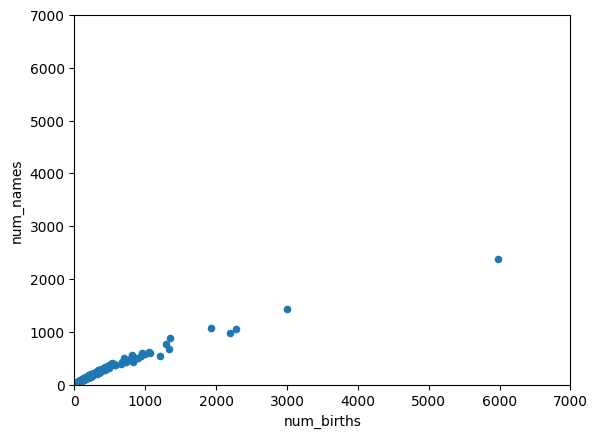

#### 3.1.2 Met random sampling

We nemen een aantal punten waarop we samples trekken 

Samples trekken: 100%|███████████████████████████████████████████████████████████████| 229/229 [00:07<00:00, 32.20it/s]


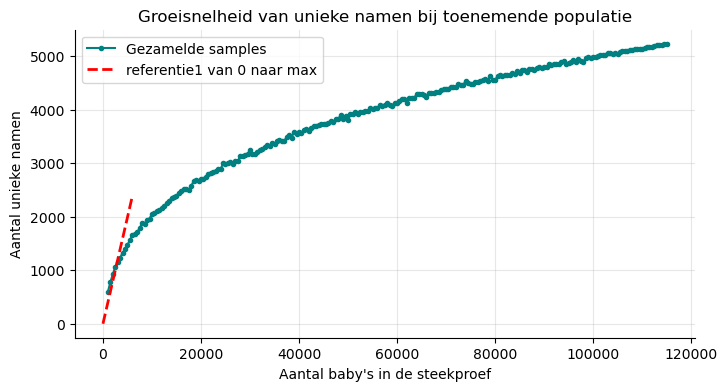

In [446]:
# EENVVOUDIGE 'MONTE CARLO' SAMPLING

# 1. Instellingen voor de sampling
# We definiëren een reeks steekproefgroottes (bijv. van 100 tot het totaal aantal baby's)
# begint bij 1.000 baby's, dan 1.500, dan 2.000, enzovoort
stap_grootte = 500
max_babies = len(df_expected_data)
sample_sizes = np.arange(1000, max_babies, stap_grootte)

results = []

# 2. De simulatie sampling loop
# tqdm voegt een visuele progress bar toe aan de loop
for n in tqdm(sample_sizes, desc="Samples trekken"):
    # Trek een willekeurige steekproef van grootte n
    # grabbelt willekeurig n baby's uit de bak met data
    # replace=False:geen 2 keer dezelfde baby
    sample = df_expected_data.sample(n=n, replace=False)
    
    # Tel het aantal unieke namen in deze sample
    num_unique = sample['naam'].nunique()
    
    results.append(num_unique) #bijv. "bij 5.000 baby's vonden we x unieke namen"

# 3. Visualisatie van de 'Groeicurve'
plt.figure(figsize=(8, 4))
plt.plot(sample_sizes, results, marker='o', markersize=3, linestyle='-', color='teal', label='Gezamelde samples')

# Vergelijking met oude Referentielijn1 voor lineair verband 
max_births = df_namen_stats['num_births'].max()
max_names = df_namen_stats['num_unique_names'].max()
# teken referentie van (0,0) tot max(x,y)
plt.plot([0, max_births], [0, max_names], 
         color='red', linewidth=2, linestyle='--', 
         label='referentie1 van 0 naar max')

plt.title('Groeisnelheid van unieke namen bij toenemende populatie')
plt.xlabel('Aantal baby\'s in de steekproef')
plt.ylabel('Aantal unieke namen')
plt.legend()
plt.grid(True, alpha=0.3)

if 'clean_plot' in globals(): clean_plot()
plt.show()

Samples trekken: 100%|███████████████████████████████████████████████████████████████| 229/229 [00:07<00:00, 32.60it/s]


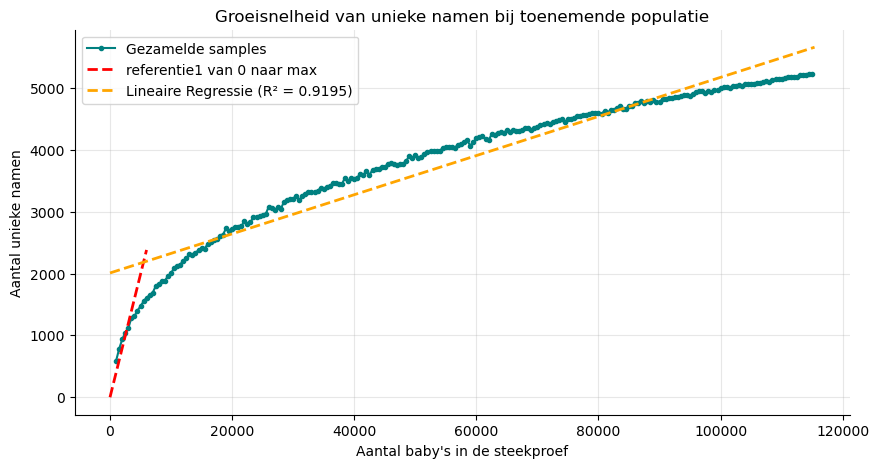

In [451]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm # Voor de voortgangsbalk

# EENVVOUDIGE 'MONTE CARLO' SAMPLING

# 1. Instellingen voor de sampling
# We definiëren een reeks steekproefgroottes (bijv. van 100 tot het totaal aantal baby's)
# begint bij 1.000 baby's, dan 1.500, dan 2.000, enzovoort
stap_grootte = 500
max_babies = len(df_expected_data)
sample_sizes = np.arange(1000, max_babies, stap_grootte)

results = []

# 2. De simulatie sampling loop
# tqdm voegt een visuele progress bar toe aan de loop
for n in tqdm(sample_sizes, desc="Samples trekken"):
    # Trek een willekeurige steekproef van grootte n
    # grabbelt willekeurig n baby's uit de bak met data
    # replace=False:geen 2 keer dezelfde baby
    sample = df_expected_data.sample(n=n, replace=False)
    
    # Tel het aantal unieke namen in deze sample
    num_unique = sample['naam'].nunique()
    
    results.append(num_unique) #bijv. "bij 5.000 baby's vonden we x unieke namen"

# --- NIEUW: LINEAIRE REGRESIE BEREKENING ---
# We fitten een 1e graads polynoom (een rechte lijn: y = ax + b) door onze samples
p = np.polyfit(sample_sizes, results, 1)

# --- NIEUW: R² BEREKENEN ---
# De correlatiecoëfficiënt (r) in het kwadraat geeft de R²
correlation_matrix = np.corrcoef(sample_sizes, results)
r_squared = correlation_matrix[0, 1]**2

# We maken een nieuwe x-as aan die exact tot 115393 loopt
x_regressie = np.linspace(0, 115393, 100)

# We berekenen de bijbehorende y-waarden met polyval
y_regressie = np.polyval(p, x_regressie)


# 3. Visualisatie van de 'Groeicurve'
plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, results, marker='o', markersize=3, linestyle='-', color='teal', label='Gezamelde samples')

# Vergelijking met oude Referentielijn1 voor lineair verband 
max_births = df_namen_stats['num_births'].max()
max_names = df_namen_stats['num_unique_names'].max()
# teken referentie van (0,0) tot max(x,y)
plt.plot([0, max_births], [0, max_names], 
         color='red', linewidth=2, linestyle='--', 
         label='referentie1 van 0 naar max')

# --- AANGEPAST: REGRESSIELIJN MET R² IN LEGENDE ---
plt.plot(x_regressie, y_regressie, color='orange', linewidth=2, 
         linestyle='--',label=f'Lineaire Regressie (R² = {r_squared:.4f})')

plt.title('Groeisnelheid van unieke namen bij toenemende populatie')
plt.xlabel('Aantal baby\'s in de steekproef')
plt.ylabel('Aantal unieke namen')
plt.legend()
plt.grid(True, alpha=0.3)

# 
#plt.xlim(0, 120000)

if 'clean_plot' in globals(): clean_plot()
plt.show()

#### VoorbeeldResult2 Vraag 3.1.2

100%|██████████| 100/100 [00:02<00:00, 45.45it/s]


#### 3.1.3  
We bekijken eerst rechstreeks het verband waar we geinteresseerd in zijn. Dit verband lijkt eerst sterk te stijgen maar vanaf 40 000 geboortes vlakt de stijging sterk af. Het verband is zeker niet linear, hoewel we vanaf de 40 000 wel van een min of meer lineair verband kunnen spreken. Om de rechte verder door te trekken, hebben we een grotere dataset nodig.

#### VoorbeeldPlot3 Vraag 3.1.3

<Axes: xlabel='n_births', ylabel='num_names'>

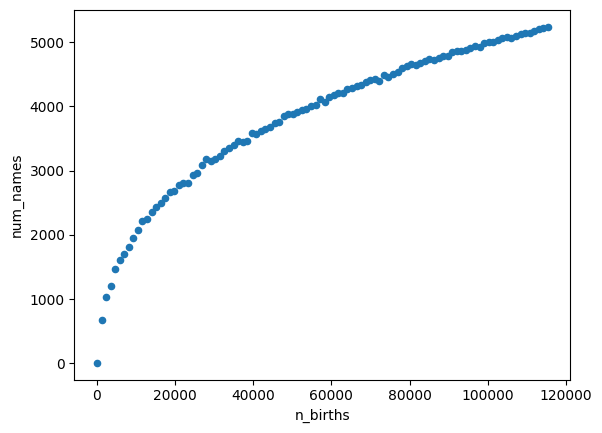

#### Vraag 3.1.4  
Een afgeleide variabele (die misschien wel interessanter is) is de frequentie van elke naam als functie van het aantal geboortes. Als we deze variabele nemen, zien we vrij snel een lineair verband ontstaan (hoewel voor minder dan 10 000 geboortes het verband niet echt lineair is). We kunnen dit verband tonen en een lineaire rechte fitten op het gedeelte met meer dan 10 000 geboortes.

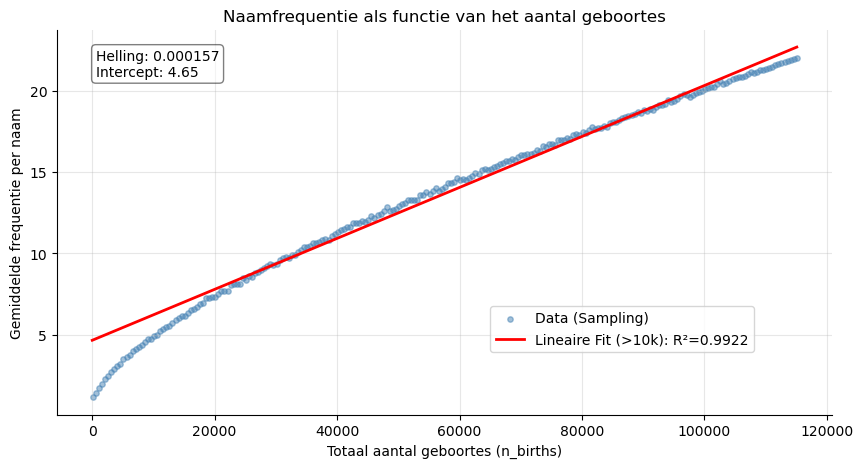

Voor elke 10.000 extra baby's worden namen gemiddeld 1.57 keer vaker gebruikt.


In [460]:
# NAAMFREQUENTIE

# --- 1. DE AFGELEIDE VARIABELE BEREKENEN ---
# We gebruiken de resultaten van de eerdere sampling.
# 'freq_names' vertelt ons: "Hoeveel baby's delen gemiddeld één naam?"
# Formule: totaal aantal baby's / aantal unieke namen
df_sampling['freq_names'] = df_sampling['n_births'] / df_sampling['num_names']

# --- 2. DE DATA FILTEREN VOOR DE FIT ---
# opstartfase negeren (< 10k) zodat  regressielijn niet wordt verbogen.
df_fit_zone = df_sampling[df_sampling['n_births'] > 10000]

# --- 3. LINEAIRE REGRESSIE (HET FITTEN) ---
# slope: de helling (hoeveel baby's per naam komen erbij per extra geboorte?)
# intercept: waar de lijn de y-as zou snijden
slope, intercept, r_val, p_val, std_err = linregress(df_fit_zone['n_births'], 
                                                     df_fit_zone['freq_names'])

# --- 4. DE FIT-LIJN VOORBEREIDEN VOOR DE PLOT ---
x_range = np.linspace(0, df_sampling['n_births'].max(), 100)
y_fit = slope * x_range + intercept

# --- 5. VISUALISATIE ---
plt.figure(figsize=(10, 5))

# De echte data-punten uit de sampling
plt.scatter(df_sampling['n_births'], df_sampling['freq_names'], 
            color='steelblue', alpha=0.5, s=15, label='Data (Sampling)')

# De berekende regressielijn (de fit)
plt.plot(x_range, y_fit, color='red', linewidth=2, 
         label=f'Lineaire Fit (>10k): R²={r_val**2:.4f}')

# --- OPMAAK EN DETAILS ---
plt.title('Naamfrequentie als functie van het aantal geboortes', fontsize=12)
plt.xlabel('Totaal aantal geboortes (n_births)')
plt.ylabel('Gemiddelde frequentie per naam')
plt.grid(True, alpha=0.3)

plt.legend(loc='upper left', bbox_to_anchor=(0.55, 0.3))
# Extra tekst in de plot om de parameters te tonen
text_info = f"Helling: {slope:.6f}\nIntercept: {intercept:.2f}"
plt.gca().text(0.05, 0.95, text_info, transform=plt.gca().transAxes, 
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

if 'clean_plot' in globals(): clean_plot()
plt.show()

# --- ANALYSE VOOR HET VERSLAG ---
print(f"Voor elke 10.000 extra baby's worden namen gemiddeld {slope*10000:.2f} keer vaker gebruikt.")

#### *** Comment Vraag 3.1.4  
**1.De 'Knik' bij 10.000:**  
Tot voor 10.000 maakt de lijn een curve. Dit is de fase waarin de "naam-pool" zich nog snel vult.

**2.De Lineaire Fase:**  
Boven de 10.000 zie je dat de punten bijna perfect op de oranje lijn gaan liggen.  
De groei van nieuwe namen vanaf dat punt wordt trager dan de groei van het aantal baby's.

**3.De Interpretatie van de Fit:**  
* De Slope (p[0]): Vertelt je hoeveel baby's er gemiddeld "bij komen" op een bestaande naam voor elke extra geboorte.

* De Intercept (p[1]): Laat zien dat als je de rechte lijn doortrekt naar 0, je niet op 0 uitkomt.  
Dit is het statistische bewijs dat het beginproces (de eerste 10.000) fundamenteel anders werkt.

#### VoorbeeldPlot4 Vraag 3.1.4

<Axes: xlabel='n_births', ylabel='freq_names'>

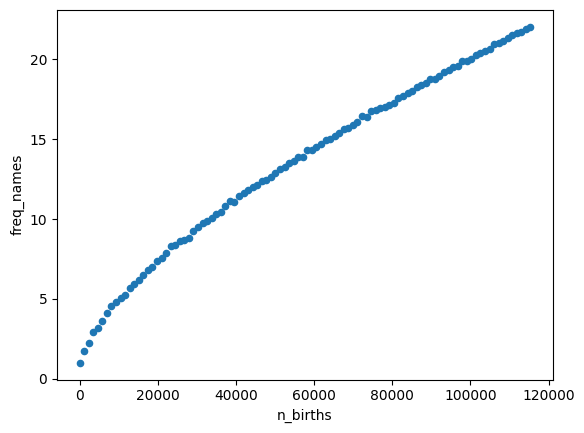

### Vraag 3.1.5 Lineaire regressie
We doen nu een lineaire regressie op de data voor `n_births > 10 000`

### Zie vorige Vraag

#### VoorbeeldResult5 Vraag 3.1.5

Intercept: 4.65287178674086
Coefficient: 0.0001563408784655592


#### VoorbeeldPlot6 Vraag 3.1.5

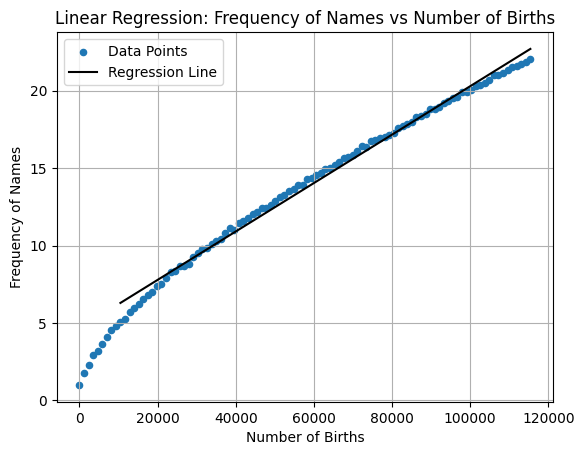

### Vraag 3.1.6 Transformatie voor lineaire regressie

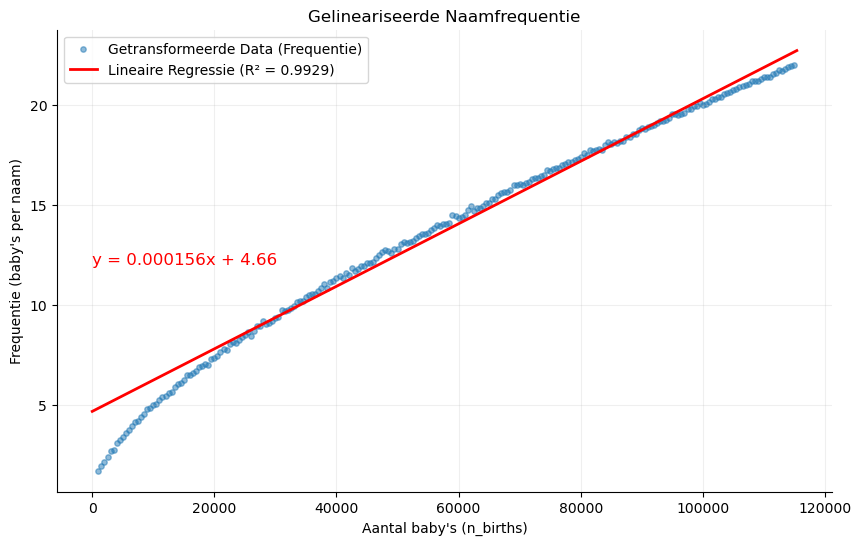

In [468]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. TRANSFORMATIE NAAR LINEAIRE VARIABELE ---
# We berekenen de frequentie: hoe vaak komt een naam gemiddeld voor?
# Gebruik de arrays die uit je Monte Carlo sampling kwamen
x_data = np.array(sample_sizes)
y_freq = x_data / np.array(results) # Frequentie = n_births / num_unique_names

# --- 2. LINEAIRE REGRESSIE MET NUMPY ---
# We fitten een 1e graads polynoom (y = ax + b)
# We gebruiken de data vanaf 10.000 om de 'opstart-curve' te negeren
mask = x_data > 10000
p = np.polyfit(x_data[mask], y_freq[mask], 1)

# Bereken R² voor de statistische onderbouwing
correlation = np.corrcoef(x_data[mask], y_freq[mask])[0, 1]
r_squared = correlation**2

# --- 3. DE LIJN GENEREREN MET POLYVAL EN LINSPACE ---
# Maak een vloeiende reeks x-waarden tot het uiterste limiet (115.393)
x_model = np.linspace(0, 115393, 200)

# Gebruik polyval om de y-waarden van de fit te berekenen voor deze x-waarden
y_model = np.polyval(p, x_model)

# --- 4. VISUALISATIE ---
plt.figure(figsize=(10, 6))

# Plot de werkelijke samples als punten
plt.scatter(x_data, y_freq, s=15, alpha=0.5, label='Getransformeerde Data (Frequentie)')

# Plot de regressielijn over het volledige bereik
plt.plot(x_model, y_model, color='red', linewidth=2, 
         label=f'Lineaire Regressie (R² = {r_squared:.4f})')

# Extra verduidelijking: toon de vergelijking in de plot
plt.text(1, 12, f'y = {p[0]:.6f}x + {p[1]:.2f}', color='red', fontsize=12)

plt.title('Gelineariseerde Naamfrequentie')
plt.xlabel('Aantal baby\'s (n_births)')
plt.ylabel('Frequentie (baby\'s per naam)')
plt.legend(loc='upper left') # Gebruik de verplaatste legende code
plt.grid(True, alpha=0.2)

clean_plot()
plt.show()

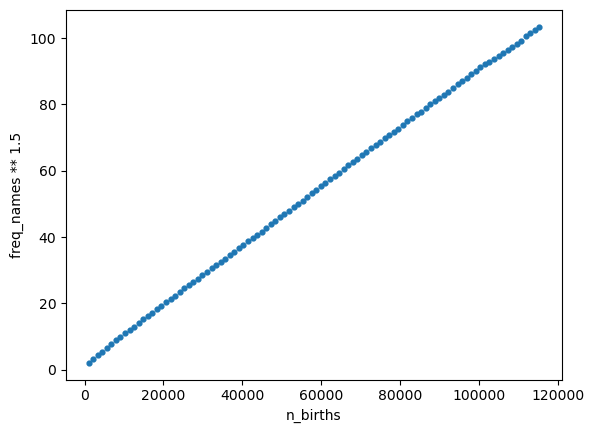

#### VoorbeeldPlot7 Vraag 3.1

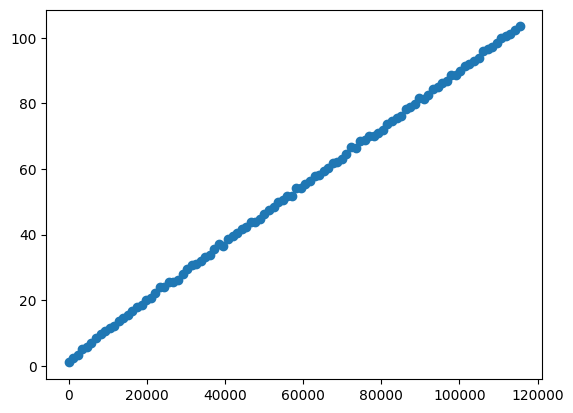

### Validatie plots
#### Valideer de accuraatheid van de frequency names 

#### VoorbeeldPlot8 Vraag 3.1

<Axes: xlabel='n_births', ylabel='freq_names'>

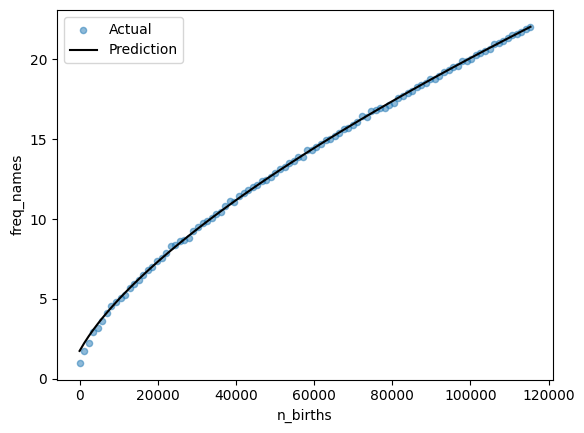

#### Valideer nu hetzelfde model zijn voorspellingen van totaal aantal verschillende namen

#### VoorbeeldPlot9 Vraag 3.1

<Axes: xlabel='n_births', ylabel='num_names'>

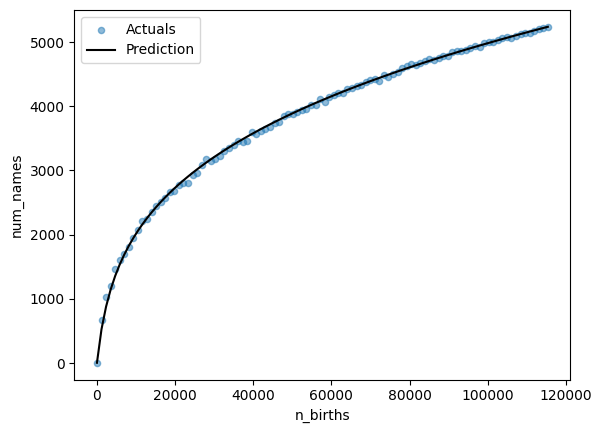

In [145]:
path11=Path(r"../data/df_expected_data.csv")
path11.parent.mkdir(parents=True, exist_ok=True)
df_expected_data.to_csv(path11, index=False, encoding="utf-8")



In [447]:
df_births_clean

,gemeente,naam,geslacht,verwachte datum,date,dag_van_jaar
534,Merksplas,Liliane,Vrouwelijk,2019-01-04,2019-01-10,10
535,Bornem,Jeroen,Mannelijk,2019-01-10,2019-01-10,10
536,Houthalen-Helchteren,Fatima,Vrouwelijk,2019-01-21,2019-01-10,10
537,Lievegem,Hilaire,Mannelijk,2019-01-15,2019-01-10,10
538,Spiere-Helkijn,Christian,Mannelijk,2019-01-16,2019-01-10,10
...,...,...,...,...,...,...
116918,Lede,Lobke,Vrouwelijk,2019-09-12,2019-09-09,252
116919,Westerlo,Willem,Mannelijk,2019-09-04,2019-09-09,252
116920,Brugge,Diane,Vrouwelijk,2019-09-20,2019-09-09,252
116921,Lendelede,Marie-Rose,Vrouwelijk,2019-10-28,2019-09-09,252
